# 🔬 Training YOLOv8n — ElectroCom61 (Versi Raspberry Pi)

Notebook ini melatih model **YOLOv8n (Nano)** untuk mendeteksi komponen elektronik pada dataset **ElectroCom61**. YOLOv8n dipilih karena ukurannya paling ringan di keluarga YOLOv8, sehingga cocok dijalankan di **Raspberry Pi 4**. Setelah training selesai, model diekspor ke format **ONNX** agar bisa dipakai langsung di Raspberry Pi. Evaluasi dan prediksi dilakukan dengan model ONNX tersebut.

## Cell 1 — Import Library & Pengecekan GPU

Cell pertama menyiapkan semua library yang dipakai di sepanjang notebook dan memeriksa apakah komputer punya GPU yang bisa dipakai PyTorch.

Library yang diimpor dan fungsinya:
- `ultralytics` (`YOLO`): library utama untuk memuat, melatih, mengevaluasi, memprediksi, dan mengekspor model YOLOv8.
- `pathlib` (`Path`): mengelola lokasi file dan folder dengan cara yang rapi, termasuk di Windows.
- `PIL` (`Image`) dan `matplotlib`: membuka gambar dan menampilkannya langsung di notebook, termasuk menggambar bounding box.
- `yaml`: membaca file `data.yaml` milik dataset.
- `torch`: dipakai untuk memeriksa ketersediaan GPU (CUDA).
- `shutil`, `os`, dan `csv`: utilitas bawaan Python untuk menyalin file dan operasi file lainnya.

Setelah itu notebook mencetak versi PyTorch, status CUDA, dan nama GPU. Variabel `DEVICE` diisi `0` (GPU pertama) kalau CUDA tersedia, atau `"cpu"` kalau tidak. Nilai ini dipakai di semua cell berikutnya. Training sebaiknya dilakukan di GPU karena di CPU prosesnya jauh lebih lambat. Raspberry Pi 4 baru dipakai nanti untuk menjalankan model yang sudah jadi, bukan untuk training.

In [1]:
from ultralytics import YOLO
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import yaml
import torch
import shutil
import os
import csv

print("PyTorch       :", torch.__version__)
print("CUDA tersedia :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU           :", torch.cuda.get_device_name(0))
    print("CUDA PyTorch  :", torch.version.cuda)
    DEVICE = 0
else:
    print("GPU tidak tersedia. Training akan menggunakan CPU (sangat lambat).")
    DEVICE = "cpu"

PyTorch       : 2.6.0+cu124
CUDA tersedia : True
GPU           : NVIDIA GeForce GTX 1650
CUDA PyTorch  : 12.4


## Cell 2 — Fungsi Menampilkan Gambar Evaluasi

Setiap kali training, validasi, atau test dijalankan, Ultralytics menyimpan sejumlah grafik evaluasi dalam bentuk file gambar (`.png`) di folder hasilnya. Cell ini membuat fungsi bantu `tampilkan_gambar_evaluasi(folder, judul)` supaya grafik-grafik itu langsung tampil di notebook tanpa perlu dibuka satu per satu dari folder.

Fungsi ini mencari file berikut di folder yang diberikan, lalu menampilkan yang ada:
- `results.png`: grafik hasil per epoch selama training (loss dan metrik). File ini hanya dibuat di folder training.
- `confusion_matrix.png` dan `confusion_matrix_normalized.png`: tabel yang menunjukkan kelas mana yang diprediksi benar dan kelas mana yang tertukar dengan kelas lain. Versi normalized menampilkannya dalam bentuk proporsi, jadi lebih mudah dibandingkan antar kelas.
- `PR_curve.png`: kurva precision terhadap recall untuk tiap kelas. Luas area di bawah kurva berkaitan dengan nilai mAP@50.
- `P_curve.png` dan `R_curve.png`: perubahan precision dan recall ketika batas confidence dinaikkan atau diturunkan.
- `F1_curve.png`: nilai F1 (gabungan precision dan recall) pada berbagai batas confidence. Kurva ini membantu memilih batas confidence yang seimbang.

Kalau sebuah file tidak ada di folder itu, file tersebut dilewati. Kalau tidak ada satu pun yang ditemukan, fungsi mencetak pesan bahwa gambar evaluasi belum tersedia.

In [2]:
def tampilkan_gambar_evaluasi(folder, judul):
    """Menampilkan file gambar evaluasi yang tersedia di folder hasil YOLO."""
    folder = Path(folder)
    nama_file = [
        "results.png",
        "confusion_matrix.png",
        "confusion_matrix_normalized.png",
        "PR_curve.png",
        "P_curve.png",
        "R_curve.png",
        "F1_curve.png",
    ]

    print(f"\n=== {judul} ===")
    ditemukan = 0

    for nama in nama_file:
        file_gambar = folder / nama
        if file_gambar.exists():
            ditemukan += 1
            img = Image.open(file_gambar).convert("RGB")
            plt.figure(figsize=(10, 7))
            plt.imshow(img)
            plt.axis("off")
            plt.title(nama)
            plt.show()

    if ditemukan == 0:
        print("Belum ada gambar evaluasi yang ditemukan pada folder:", folder)

print("Fungsi tampilkan_gambar_evaluasi() siap digunakan.")

Fungsi tampilkan_gambar_evaluasi() siap digunakan.


## Cell 3 — Menentukan Lokasi Dataset

Cell ini menentukan di mana dataset ElectroCom61 disimpan di komputer. Variabel `dataset_path` berisi lokasi folder dataset, dan `yaml_path` menunjuk ke file `data.yaml` di dalamnya.

Folder dataset harus punya struktur yang diharapkan YOLO: folder `train`, `valid`, dan `test` (masing-masing berisi subfolder `images` dan `labels`), ditambah file `data.yaml`. File `data.yaml` inilah yang nanti diberikan ke Ultralytics sebagai sumber informasi dataset.

Sebelum lanjut, notebook memeriksa apakah folder dan file tersebut benar-benar ada, lalu mencetak hasilnya. Kalau salah satunya tidak ditemukan, notebook langsung berhenti dengan pesan error yang jelas. Dengan begitu kesalahan path ketahuan di awal, bukan di tengah proses training. Kalau dataset kamu ada di lokasi lain, ubah nilai `dataset_path` di cell ini.

In [3]:
dataset_path = Path(
    r"D:\Downloads\ElectroCom61\ElectroCom61 A Multiclass Dataset for Detection of Electronic Components\ElectroCom-61_v2"
)

yaml_path = dataset_path / "data.yaml"

print("Dataset ditemukan :", dataset_path.exists())
print("data.yaml ditemukan:", yaml_path.exists())
print("Lokasi dataset    :", dataset_path)

if not dataset_path.exists():
    raise FileNotFoundError(
        "Dataset tidak ditemukan. Periksa kembali nilai dataset_path."
    )

if not yaml_path.exists():
    raise FileNotFoundError(
        "data.yaml tidak ditemukan di folder dataset."
    )

print("\nDataset berhasil ditemukan! ✅")

Dataset ditemukan : True
data.yaml ditemukan: True
Lokasi dataset    : D:\Downloads\ElectroCom61\ElectroCom61 A Multiclass Dataset for Detection of Electronic Components\ElectroCom-61_v2

Dataset berhasil ditemukan! ✅


## Cell 4 — Membaca data.yaml

`data.yaml` adalah file konfigurasi dataset untuk YOLO. Cell ini membukanya dengan library `yaml`, lalu menyimpan isinya di variabel `data`.

Informasi yang dipakai dari file ini:
- `nc`: jumlah kelas komponen elektronik yang ada di dataset.
- `names`: daftar nama kelas. Urutannya penting, karena angka `class_id` di file label menunjuk ke posisi nama di daftar ini. Misalnya `class_id` 0 berarti nama pertama dalam daftar.

Notebook mencetak jumlah kelas, jumlah nama, dan seluruh daftar kelas beserta nomornya. Jumlah nama harus sama dengan `nc`. Variabel `data` ini juga dipakai lagi nanti untuk menampilkan nama kelas pada visualisasi ground truth dan hasil prediksi.

In [4]:
with open(yaml_path, "r", encoding="utf-8") as f:
    data = yaml.safe_load(f)

print("Jumlah kelas :", data["nc"])
print("Jumlah nama  :", len(data["names"]))

print("\nDaftar kelas:")
for i, name in enumerate(data["names"]):
    print(f"{i:2d}: {name}")

Jumlah kelas : 61
Jumlah nama  : 61

Daftar kelas:
 0: 1-5-Volt-Battery
 1: 3-3-Volt-Battery
 2: 7-Segment-Display
 3: 9-Volt-Battery
 4: Arduino-Mega
 5: Arduino-Nano
 6: Arduino-Uno
 7: BJT-Transistor
 8: Bluetooth-Module
 9: Breadboard
10: Bridge-Rectifier
11: Buck-Converter
12: Buzzer
13: Capacitor-10mf
14: Capacitor-470mf
15: DC-Motor
16: Diode
17: ESP32
18: ESP32-CAM
19: FT-232-USB-Serial-Module
20: Film-Capacitor
21: Fuse
22: Fuse-Base
23: GSM-Module
24: Gas-Sensor
25: Heat-Sink
26: High-Voltage-Ceramic-Capacitor
27: Humidity-Sensor
28: IC-Base-14-Pin
29: IC-Base-28-Pin
30: IC-Chip
31: IGBT
32: IR-Sensor
33: Inductor
34: Keypad
35: LCD-Display
36: LDR-Sensor
37: LED-Light
38: Low-Voltage-Ceramic-Capacitor
39: MLC-Capacitor
40: MOSFET
41: Motion-Sensor
42: Motor-Driver
43: NTC-Thermistor
44: OLED-Display
45: Pin-Header
46: Push-Switch
47: RFID-Scanner
48: Raindrops-Module
49: Relay-Module
50: Resistor
51: Rocker-Switch
52: Servo-Motor
53: Soil-Moisture-Sensor
54: Sonar-Sensor
55:

## Cell 5 — Mengecek Jumlah Gambar dan Label

Dataset dibagi menjadi tiga bagian, dan masing-masing punya peran berbeda:
- `train`: data untuk melatih model.
- `valid`: data untuk memantau performa selama training dan memilih bobot terbaik.
- `test`: data untuk pengujian akhir, yang tidak dipakai saat training.

Cell ini menghitung jumlah file gambar (dengan ekstensi `.jpg`, `.jpeg`, `.png`, `.bmp`, atau `.webp`) dan jumlah file label `.txt` di setiap bagian, lalu mencetak totalnya. Setiap gambar punya satu file label dengan nama yang sama, jadi jumlah gambar dan label biasanya sama. Kalau ada selisih, penyebabnya dicari lewat pemeriksaan di cell berikutnya. Hasil cell ini juga memberi gambaran ukuran tiap bagian dataset sebelum training dimulai.

In [5]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
split_counts = {}

for split in ["train", "valid", "test"]:
    images_path = dataset_path / split / "images"
    labels_path = dataset_path / split / "labels"

    images = [
        p for p in images_path.iterdir()
        if p.is_file() and p.suffix.lower() in image_extensions
    ]
    labels = list(labels_path.glob("*.txt"))

    split_counts[split] = {
        "images": len(images),
        "labels": len(labels)
    }

    print(f"===== {split.upper()} =====")
    print("Images :", len(images))
    print("Labels :", len(labels))
    print()

total_images = sum(v["images"] for v in split_counts.values())
print("TOTAL IMAGES:", total_images)

===== TRAIN =====
Images : 1478
Labels : 1478

===== VALID =====
Images : 438
Labels : 438

===== TEST =====
Images : 205
Labels : 205

TOTAL IMAGES: 2121


## Cell 6 — Validasi Label YOLO

Label YOLO ditulis satu objek per baris dengan format:

`class_id x_center y_center width height`

Empat angka terakhir adalah koordinat bounding box yang sudah dinormalisasi terhadap ukuran gambar, sehingga nilainya harus berada di antara 0 dan 1. Label yang rusak bisa membuat training berhenti dengan error atau diam-diam menurunkan kualitas model, jadi cell ini memeriksanya lebih dulu.

Ada tiga pemeriksaan yang dilakukan di `train`, `valid`, dan `test`:
- **Image tanpa label**: ada gambar yang tidak punya file label dengan nama yang sama.
- **Label tanpa image**: ada file label yang gambarnya tidak ada.
- **Label bermasalah**: isi baris tidak sesuai, yaitu jumlah nilainya bukan lima, `class_id` di luar rentang `0` sampai `nc - 1`, koordinat di luar rentang 0 sampai 1, atau file tidak bisa dibaca.

Hasilnya dicetak dalam bentuk jumlah masalah, dan sampai sepuluh contoh ditampilkan kalau ada label bermasalah. Kalau semuanya nol, label siap dipakai untuk training.

In [6]:
invalid_labels = []
missing_labels = []
orphan_labels  = []

for split in ["train", "valid", "test"]:
    images_path = dataset_path / split / "images"
    labels_path = dataset_path / split / "labels"

    images = [
        p for p in images_path.iterdir()
        if p.is_file() and p.suffix.lower() in image_extensions
    ]
    labels = list(labels_path.glob("*.txt"))

    image_stems = {p.stem for p in images}
    label_stems = {p.stem for p in labels}

    for stem in sorted(image_stems - label_stems):
        missing_labels.append((split, stem))

    for stem in sorted(label_stems - image_stems):
        orphan_labels.append((split, stem))

    for label_file in labels:
        try:
            with open(label_file, "r", encoding="utf-8") as f:
                for line_number, line in enumerate(f, start=1):
                    line = line.strip()
                    if not line:
                        continue
                    values = line.split()
                    if len(values) != 5:
                        invalid_labels.append(
                            (split, label_file.name, line_number, "Jumlah nilai bukan 5")
                        )
                        continue
                    class_id = int(float(values[0]))
                    coords   = [float(v) for v in values[1:]]
                    if not (0 <= class_id < data["nc"]):
                        invalid_labels.append(
                            (split, label_file.name, line_number, "Class ID tidak valid")
                        )
                    if not all(0 <= v <= 1 for v in coords):
                        invalid_labels.append(
                            (split, label_file.name, line_number, "Koordinat di luar 0-1")
                        )
        except Exception as e:
            invalid_labels.append(
                (split, label_file.name, 0, f"Gagal dibaca: {e}")
            )

print("Label bermasalah  :", len(invalid_labels))
print("Image tanpa label :", len(missing_labels))
print("Label tanpa image :", len(orphan_labels))

if invalid_labels:
    print("\nContoh masalah:")
    for item in invalid_labels[:10]:
        print(item)
else:
    print("\nSemua label yang diperiksa memiliki format yang valid. ✅")

Label bermasalah  : 0
Image tanpa label : 0
Label tanpa image : 0

Semua label yang diperiksa memiliki format yang valid. ✅


## Cell 7 — Jumlah Objek per Kelas

Cell ini menghitung berapa kali setiap jenis komponen muncul di dataset, lalu menampilkannya dalam satu tabel dan satu grafik. Dengan begitu kamu bisa melihat semua kelas sekaligus beserta jumlah objeknya.

Yang dihitung adalah **jumlah objek**, bukan jumlah gambar. Satu gambar bisa berisi beberapa komponen, dan setiap baris di file label dihitung sebagai satu objek. Penghitungan dilakukan dengan membaca seluruh file label di folder `train`, `valid`, dan `test`, lalu mengelompokkan baris berdasarkan `class_id` dan mengubahnya ke nama kelas dari `data.yaml`.

Hasil yang ditampilkan:
- **Tabel:** setiap kelas lengkap dengan ID, nama, jumlah objek di `train`, `valid`, `test`, dan totalnya. Baris paling bawah berisi jumlah keseluruhan. Tabel diurutkan sesuai ID kelas.
- **Ringkasan:** kelas dengan objek terbanyak dan tersedikit di data `train`, serta kelas yang tidak punya contoh di salah satu bagian dataset.
- **Grafik batang:** jumlah objek per kelas pada data `train`, diurutkan dari yang terbanyak. Grafik ini memperlihatkan apakah datanya seimbang atau ada kelas yang jauh lebih sedikit dari yang lain.

Informasi ini penting untuk membaca hasil evaluasi nanti. Kelas dengan contoh training sedikit biasanya lebih sulit dikenali model, jadi nilai precision dan recall-nya cenderung lebih rendah.

 ID  Kelas                            Train   Valid    Test   Total
-----------------------------------------------------------------
  0  1-5-Volt-Battery                    94     109       8     211
  1  3-3-Volt-Battery                    77      38      90     205
  2  7-Segment-Display                  131      36      17     184
  3  9-Volt-Battery                     160       0       0     160
  4  Arduino-Mega                       129      29      19     177
  5  Arduino-Nano                        77     105      12     194
  6  Arduino-Uno                        201       5       1     207
  7  BJT-Transistor                     102     100      27     229
  8  Bluetooth-Module                   249       0       0     249
  9  Breadboard                         130      31      20     181
 10  Bridge-Rectifier                   162      45      23     230
 11  Buck-Converter                     117      33      18     168
 12  Buzzer                             272       

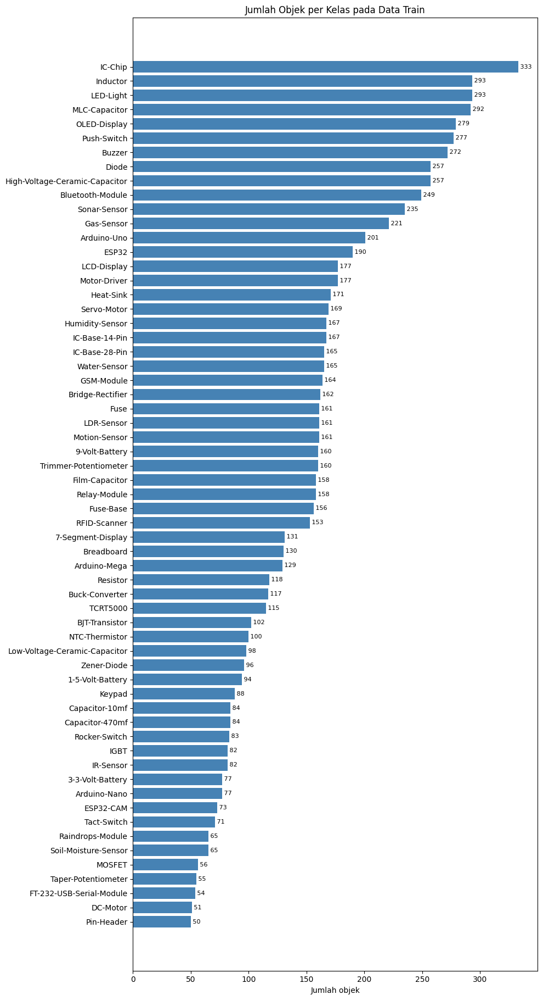

In [7]:
from collections import Counter

splits       = ["train", "valid", "test"]
jumlah_objek = {split: Counter() for split in splits}

for split in splits:
    labels_path = dataset_path / split / "labels"
    for label_file in labels_path.glob("*.txt"):
        with open(label_file, "r", encoding="utf-8") as f:
            for line in f:
                values = line.strip().split()
                if len(values) != 5:
                    continue
                jumlah_objek[split][int(float(values[0]))] += 1

nama_kelas = data["names"]
jumlah_kelas = len(nama_kelas)

# ---------- Tabel jumlah objek per kelas ----------
print(f"{'ID':>3}  {'Kelas':<30}{'Train':>8}{'Valid':>8}{'Test':>8}{'Total':>8}")
print("-" * 65)

for class_id in range(jumlah_kelas):
    n_train = jumlah_objek["train"][class_id]
    n_valid = jumlah_objek["valid"][class_id]
    n_test  = jumlah_objek["test"][class_id]
    total   = n_train + n_valid + n_test
    print(f"{class_id:>3}  {nama_kelas[class_id]:<30}{n_train:>8}{n_valid:>8}{n_test:>8}{total:>8}")

total_train = sum(jumlah_objek["train"].values())
total_valid = sum(jumlah_objek["valid"].values())
total_test  = sum(jumlah_objek["test"].values())

print("-" * 65)
print(f"{'':>3}  {'TOTAL OBJEK':<30}{total_train:>8}{total_valid:>8}{total_test:>8}{total_train + total_valid + total_test:>8}")

# ---------- Ringkasan ----------
train_per_kelas = {k: jumlah_objek["train"][k] for k in range(jumlah_kelas)}
terbanyak = max(train_per_kelas, key=train_per_kelas.get)
tersedikit = min(train_per_kelas, key=train_per_kelas.get)

print(f"\nKelas terbanyak di train : {nama_kelas[terbanyak]} ({train_per_kelas[terbanyak]} objek)")
print(f"Kelas tersedikit di train: {nama_kelas[tersedikit]} ({train_per_kelas[tersedikit]} objek)")

for split in splits:
    kosong = [nama_kelas[k] for k in range(jumlah_kelas) if jumlah_objek[split][k] == 0]
    if kosong:
        print(f"Kelas tanpa contoh di {split}: {', '.join(kosong)}")

# ---------- Grafik jumlah objek per kelas (data train) ----------
urutan = sorted(range(jumlah_kelas), key=lambda k: train_per_kelas[k], reverse=True)
nama   = [nama_kelas[k] for k in urutan]
nilai  = [train_per_kelas[k] for k in urutan]

fig, ax = plt.subplots(figsize=(10, max(6, 0.3 * jumlah_kelas)))
batang = ax.barh(nama, nilai, color="steelblue")
ax.invert_yaxis()
ax.set_xlabel("Jumlah objek")
ax.set_title("Jumlah Objek per Kelas pada Data Train")

for b, v in zip(batang, nilai):
    ax.text(v, b.get_y() + b.get_height() / 2, f" {v}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

## Cell 8 — Menampilkan Ground Truth (Contoh Gambar Berlabel)

Ground truth adalah anotasi asli dari dataset, yaitu kotak dan nama kelas yang ditandai manusia pada setiap objek. Cell ini menampilkan satu gambar dari folder `train` lengkap dengan anotasinya.

Caranya: file label gambar itu dibaca, lalu koordinat YOLO yang berbentuk proporsi (pusat, lebar, tinggi) diubah menjadi koordinat piksel sesuai ukuran gambar. Setelah itu setiap objek digambar sebagai kotak hijau dengan nama kelasnya di atas kotak. Kalau file label gambar tidak ditemukan, notebook mencetak pesannya.

Tujuan cell ini adalah pemeriksaan visual. Kotak harus menempel pada komponen yang benar, dan nama kelasnya harus sesuai dengan komponennya. Kalau kotak melenceng atau nama kelasnya salah, berarti ada masalah di dataset atau di `data.yaml` yang perlu diperbaiki sebelum training.

Menampilkan 5 contoh gambar berlabel dari folder train.


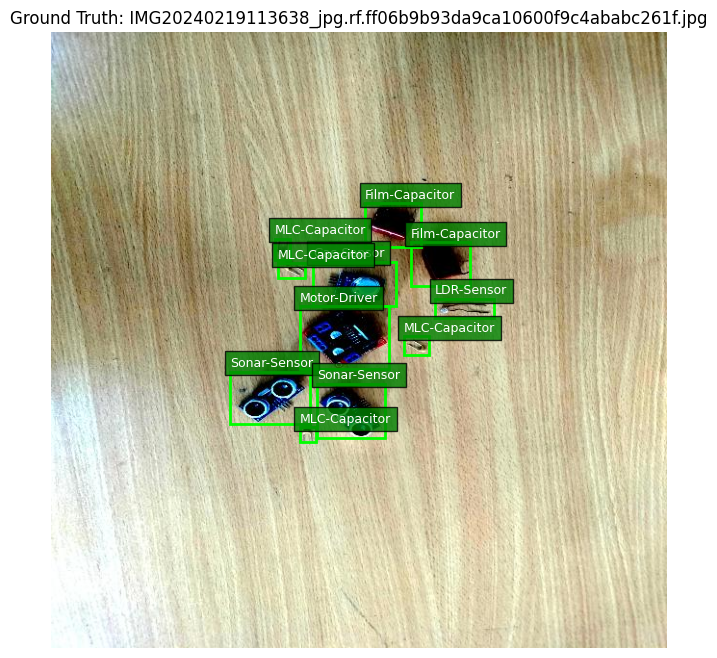

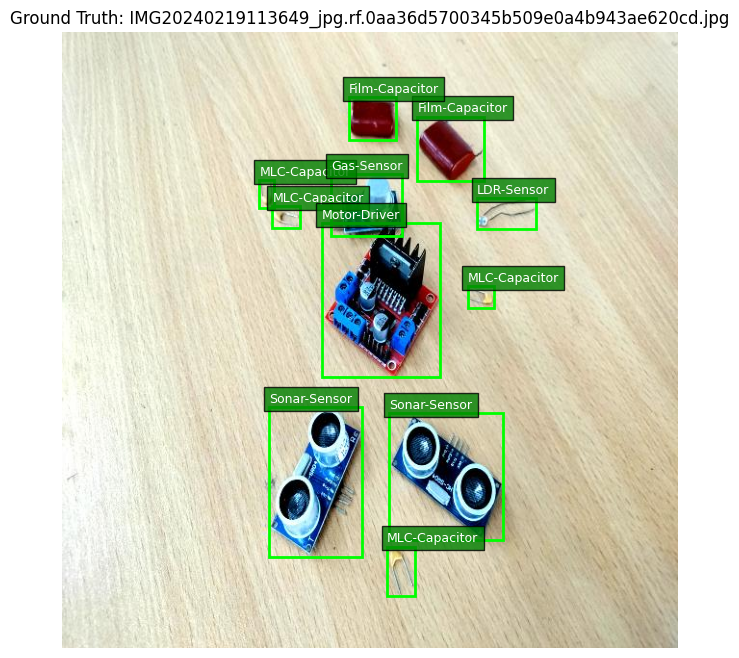

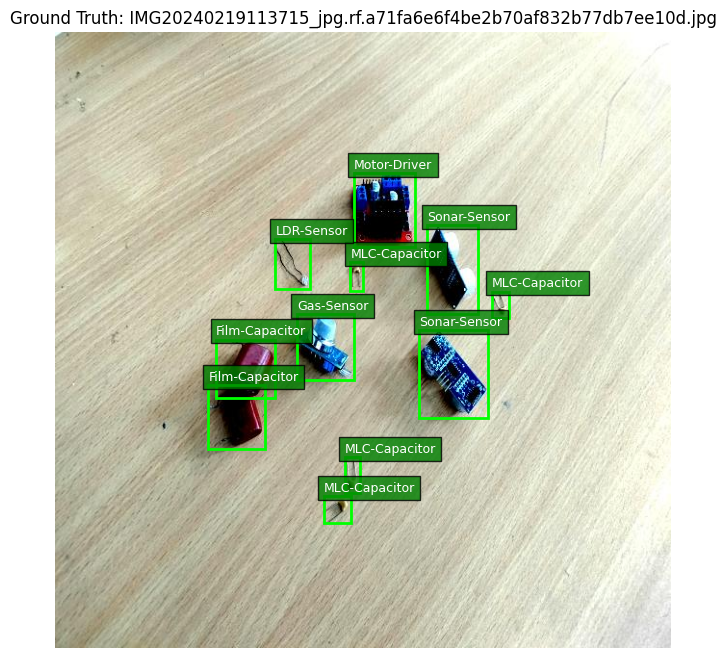

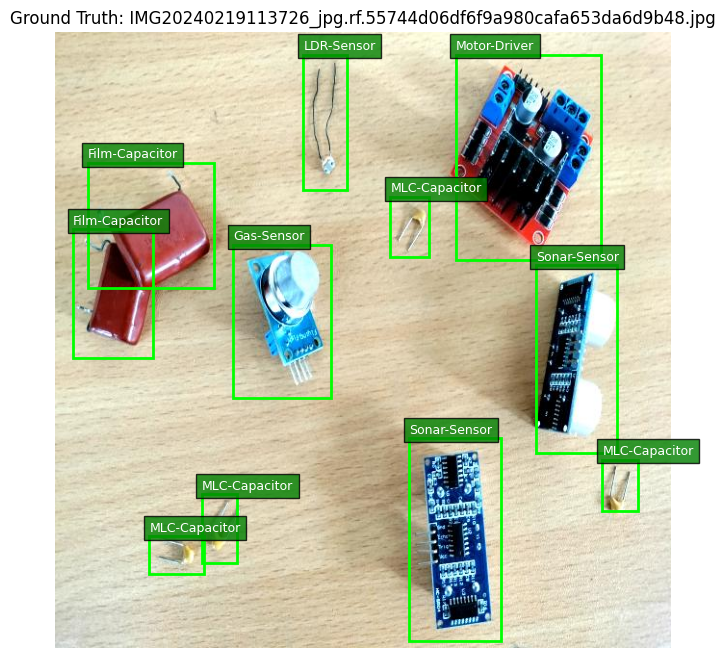

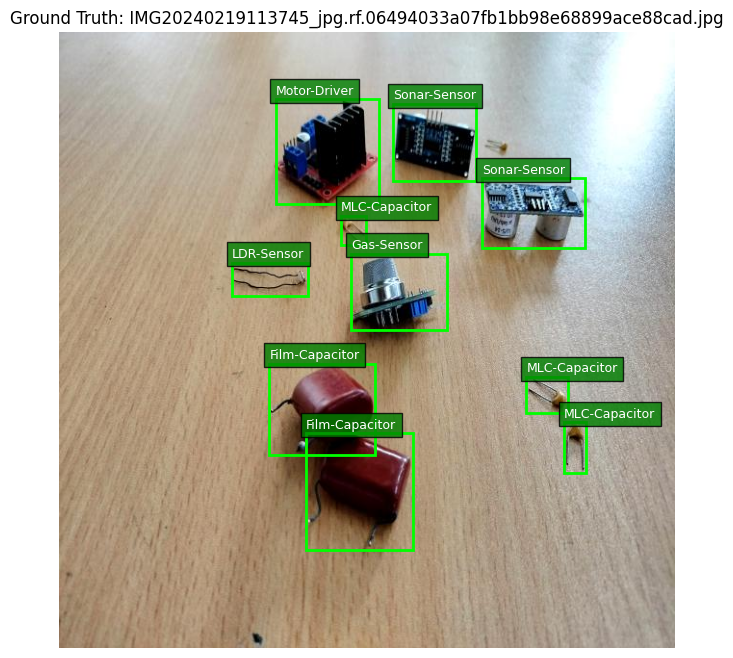

In [8]:
def show_ground_truth(image_path):
    image      = Image.open(image_path).convert("RGB")
    label_path = dataset_path / "train" / "labels" / f"{image_path.stem}.txt"

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(image)

    if label_path.exists():
        with open(label_path, "r", encoding="utf-8") as f:
            for line in f:
                values = line.strip().split()
                if len(values) != 5:
                    continue
                class_id = int(float(values[0]))
                x_center, y_center, width, height = map(float, values[1:])
                img_w, img_h = image.size
                box_w = width  * img_w
                box_h = height * img_h
                x     = (x_center * img_w) - box_w / 2
                y     = (y_center * img_h) - box_h / 2
                rect  = patches.Rectangle(
                    (x, y), box_w, box_h,
                    fill=False, linewidth=2, edgecolor="lime"
                )
                ax.add_patch(rect)
                ax.text(
                    x, max(0, y - 5),
                    data["names"][class_id],
                    fontsize=9, color="white",
                    bbox=dict(facecolor="green", alpha=0.8)
                )
    else:
        print("File label tidak ditemukan:", label_path)

    ax.set_title(f"Ground Truth: {image_path.name}")
    ax.axis("off")
    plt.show()

train_images = sorted([
    p for p in (dataset_path / "train" / "images").iterdir()
    if p.is_file() and p.suffix.lower() in image_extensions
])

jumlah_contoh = min(5, len(train_images))
print(f"Menampilkan {jumlah_contoh} contoh gambar berlabel dari folder train.")

for image_path in train_images[:jumlah_contoh]:
    show_ground_truth(image_path)

## Cell 9 — Load Model YOLOv8n (Nano)

Cell ini memuat model **YOLOv8n** dari file bobot `yolov8n.pt`. Huruf `n` berarti *nano*, varian YOLOv8 yang paling kecil dan ringan, jadi sesuai untuk perangkat dengan CPU terbatas seperti Raspberry Pi 4. File bobot akan diunduh otomatis kalau belum ada di komputer.

Bobot ini adalah bobot *pretrained*, yaitu model yang sudah dilatih lebih dulu pada dataset besar (COCO) sehingga sudah mengenali ciri dasar gambar seperti tepi, bentuk, dan tekstur. Training di dataset ElectroCom61 nanti tidak mulai dari nol, melainkan menyesuaikan bobot ini supaya mengenali komponen elektronik. Cara ini disebut transfer learning dan biasanya lebih cepat dan lebih stabil dibanding melatih dari awal.

Notebook mencetak pesan berhasil dimuat dan jumlah parameter model sebagai gambaran ukuran modelnya.

In [9]:
# YOLOv8n (Nano) — ringan, cocok untuk Raspberry Pi 4
model = YOLO("yolov8n.pt")
print("YOLOv8n pretrained berhasil dimuat.")
print(f"Jumlah parameter model: {sum(p.numel() for p in model.model.parameters()):,}")

YOLOv8n pretrained berhasil dimuat.
Jumlah parameter model: 3,157,200


## Cell 10 — Konfigurasi Training

Cell ini mengumpulkan semua pengaturan training di satu tempat supaya mudah dibaca dan diubah.

**Folder keluaran:**
- `PROJECT_DIR`: folder `electrocom61_yolov8n_runs` tempat semua hasil training, validasi, test, dan prediksi disimpan. Folder dibuat otomatis kalau belum ada.
- `MODELS_DIR`: folder `models` tempat file `best.onnx` akan disalin pada Cell 13.

**`BASE_CONFIG` (pengaturan umum):**
- `optimizer`: Adam, algoritma yang memperbarui bobot model.
- `lr0`: learning rate awal 0,001, yaitu besar langkah pembaruan bobot di awal training.
- `device`: GPU atau CPU, sesuai hasil pengecekan di Cell 1.
- `workers`: jumlah proses yang memuat data secara paralel.
- `pretrained`: memakai bobot pretrained sebagai titik awal.
- `plots`: menyimpan grafik hasil training.
- `verbose`: menampilkan log training secara rinci.

**`TRAIN_CONFIG` (pengaturan training):**
- `epochs` = 50: batas maksimum jumlah epoch. Satu epoch berarti seluruh data training dilewati satu kali. Training bisa berhenti sebelum epoch ke-50 kalau early stopping aktif (lihat `patience`).
- `patience` = 10: pengaturan **early stopping**. Setelah setiap epoch, Ultralytics memeriksa apakah performa di data `valid` membaik. Kalau selama 10 epoch berturut-turut tidak ada perbaikan, training dihentikan otomatis dan bobot terbaik tetap tersimpan sebagai `best.pt`. Nilai yang dipantau adalah skor gabungan mAP50 dan mAP50-95 (bobotnya 0,1 dan 0,9). Early stopping menghemat waktu dan mengurangi risiko overfitting.
- `imgsz` = 640: setiap gambar diubah ke ukuran 640 piksel sebelum diproses. Ukuran ini lebih ringan, jadi training lebih cepat dan model lebih mudah dijalankan di Raspberry Pi, dengan konsekuensi detail komponen yang sangat kecil sedikit berkurang. Ukuran harus kelipatan 32.
- `batch` = 8: jumlah gambar yang diproses dalam satu langkah. Kalau muncul error *CUDA out of memory*, turunkan ke 4.
- `name`: nama subfolder untuk hasil training ini.

In [10]:
# Folder output hasil training
PROJECT_DIR = Path.cwd() / "electrocom61_yolov8n_runs"
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

# Folder model aplikasi (best.onnx akan disalin ke sini)
MODELS_DIR = Path.cwd() / "models"
MODELS_DIR.mkdir(exist_ok=True)

# Konfigurasi dasar
BASE_CONFIG = {
    "optimizer" : "Adam",
    "lr0"       : 0.001,
    "device"    : DEVICE,
    "workers"   : 2,
    "pretrained": True,
    "plots"     : True,
    "verbose"   : True,
}

# Konfigurasi training
TRAIN_CONFIG = {
    "epochs"  : 50,    # batas maksimum epoch
    "patience": 10,    # early stopping: berhenti jika 10 epoch berturut-turut tidak membaik
    "imgsz"   : 640,
    "batch"   : 8,
    "name"    : "yolov8n_50epoch_640",
}

print("Konfigurasi training :", TRAIN_CONFIG)

Konfigurasi training : {'epochs': 50, 'patience': 10, 'imgsz': 640, 'batch': 8, 'name': 'yolov8n_50epoch_640'}


## Cell 11 — Training Model

Cell ini menjalankan training. Model YOLOv8n pretrained dimuat, lalu dilatih pada dataset ElectroCom61 memakai `data.yaml`, pengaturan di `BASE_CONFIG`, dan konfigurasi di `TRAIN_CONFIG` (maksimal 50 epoch, early stopping dengan `patience` 10, ukuran gambar 640, batch size 8).

Selama training, setiap epoch terdiri dari dua tahap. Pertama, model belajar dari data `train` dan bobotnya diperbarui. Kedua, model dicoba pada data `valid` untuk melihat apakah performanya membaik. Kemajuan tiap epoch ditampilkan di log, berisi nilai loss dan metrik validasi.

Karena early stopping aktif, training berhenti lebih awal kalau performa validasi tidak membaik selama 10 epoch berturut-turut. Di log akan muncul pesan `EarlyStopping` yang menyebut epoch terbaiknya. Perlu diingat bahwa yang disimpan sebagai `best.pt` adalah epoch terbaik, bukan epoch saat training berhenti. Kalau epoch terbaik jatuh di epoch 40, misalnya, training baru berhenti di epoch 50, jadi tidak ada epoch yang terpotong. Training baru berhenti sebelum epoch ke-50 kalau epoch terbaiknya lebih awal dari epoch 40.

Hasil training disimpan di `PROJECT_DIR/yolov8n_50epoch_640`. Di dalam subfolder `weights` ada dua file bobot:
- `best.pt`: bobot dari epoch dengan performa validasi terbaik. File inilah yang diekspor ke ONNX pada Cell 13.
- `last.pt`: bobot dari epoch terakhir.

Folder itu juga berisi grafik hasil training seperti `results.png`. Setelah training selesai, notebook mencetak lokasi folder hasil dan memastikan `best.pt` ada.

> ⏱️ **Waktu training** tergantung komputer, dan bisa lebih singkat kalau early stopping aktif. Jangan tutup Jupyter atau matikan laptop selama proses berjalan.

Ultralytics selalu menyimpan bobot training dalam bentuk `.pt`. File itu hanya menjadi bahan untuk export, dan setelah Cell 13 tidak dipakai lagi.

In [11]:
print("=" * 60)
print(
    f"TRAINING — YOLOv8n | max {TRAIN_CONFIG['epochs']} epoch | "
    f"patience={TRAIN_CONFIG['patience']} | imgsz={TRAIN_CONFIG['imgsz']} | batch={TRAIN_CONFIG['batch']}"
)
print("=" * 60)

model_train   = YOLO("yolov8n.pt")
results_train = model_train.train(
    data    = str(yaml_path),
    epochs  = TRAIN_CONFIG["epochs"],
    patience= TRAIN_CONFIG["patience"],
    imgsz   = TRAIN_CONFIG["imgsz"],
    batch   = TRAIN_CONFIG["batch"],
    project = str(PROJECT_DIR),
    name    = TRAIN_CONFIG["name"],
    **BASE_CONFIG
)

run_dir       = Path(results_train.save_dir)
best_pt       = run_dir / "weights" / "best.pt"

print("\nTraining selesai.")
print("Folder hasil :", run_dir)
print("best.pt      :", best_pt)
print("best.pt ada  :", best_pt.exists())

TRAINING — YOLOv8n | max 50 epoch | patience=10 | imgsz=640 | batch=8
New https://pypi.org/project/ultralytics/8.4.174 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.152  Python-3.10.21 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\Downloads\ElectroCom61\ElectroCom61 A Multiclass Dataset for Detection of Electronic Components\ElectroCom-61_v2\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, h

## Cell 12 — Grafik Hasil Training

Selama training, Ultralytics mencatat nilai loss dan metrik di setiap epoch, lalu menggambarnya dalam satu file `results.png` di folder hasil training. Cell ini menampilkan grafik itu langsung di notebook. Grafik ini menunjukkan bagaimana model belajar dari epoch pertama sampai terakhir, sehingga paling berguna untuk menilai apakah training berjalan sehat.

`results.png` berisi sepuluh grafik kecil. Tiap grafik punya garis hasil per epoch dan garis versi yang sudah dihaluskan agar kecenderungannya lebih mudah dilihat:
- **Loss training** (`train/box_loss`, `train/cls_loss`, `train/dfl_loss`): ukuran kesalahan model pada data train. `box_loss` untuk posisi dan ukuran kotak, `cls_loss` untuk kesalahan kelas, dan `dfl_loss` untuk ketepatan tepi kotak. Nilainya seharusnya turun dari epoch ke epoch.
- **Loss validasi** (`val/box_loss`, `val/cls_loss`, `val/dfl_loss`): tiga loss yang sama, tetapi dihitung pada data `valid`.
- **Metrik validasi** (`metrics/precision(B)`, `metrics/recall(B)`, `metrics/mAP50(B)`, `metrics/mAP50-95(B)`): huruf B berarti bounding box. Nilainya seharusnya naik, lalu mulai mendatar.

Cara membacanya:
- Loss training dan loss validasi sama-sama turun lalu melandai, dan metrik naik lalu mendatar: training berjalan sehat.
- Loss training terus turun tetapi loss validasi mulai naik: tanda overfitting, yaitu model terlalu menghafal data train.
- Metrik masih naik jelas sampai epoch terakhir: model mungkin belum selesai belajar, jadi jumlah epoch bisa ditambah.

Grafik ini bisa dijadikan lampiran di laporan sebagai bukti proses training.

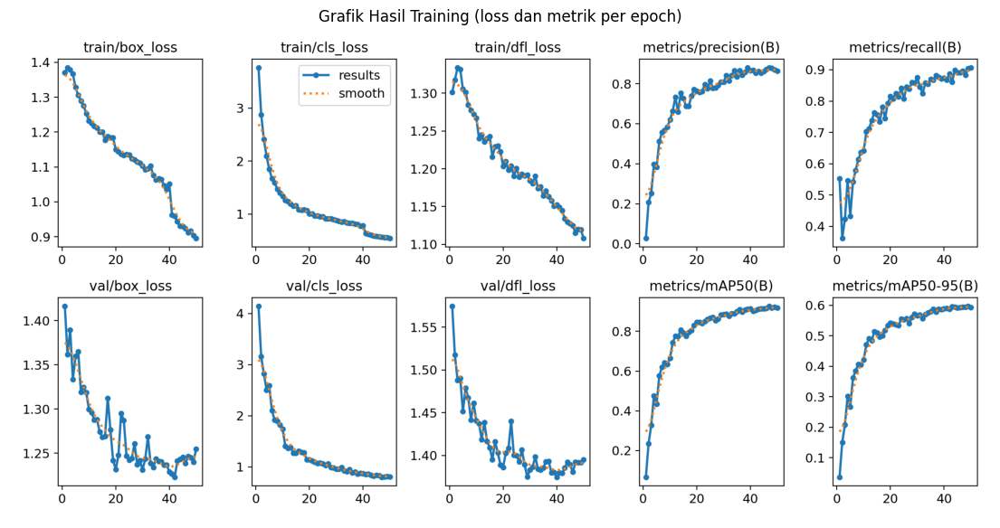

In [12]:
grafik_training = run_dir / "results.png" if "run_dir" in globals() else None

if grafik_training is not None and grafik_training.exists():
    img = Image.open(grafik_training).convert("RGB")
    plt.figure(figsize=(14, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Grafik Hasil Training (loss dan metrik per epoch)")
    plt.show()
else:
    print("results.png tidak ditemukan.")
    print("Jalankan Cell 11 (training) terlebih dahulu.")

## Cell 13 — Export Model ke Format ONNX

ONNX (Open Neural Network Exchange) adalah format model yang bisa dijalankan oleh `onnxruntime` tanpa PyTorch dan Ultralytics. Itu yang membuatnya praktis untuk Raspberry Pi 4, karena yang perlu dipasang di sana hanya `onnxruntime`.

Cell ini melakukan lima hal:
1. Memuat `best.pt` hasil training.
2. Mengekspornya ke format ONNX. `imgsz` disamakan dengan ukuran saat training (640), `simplify=True` menyederhanakan struktur model supaya lebih ringan dijalankan di CPU, dan `dynamic=False` mengunci ukuran input pada 640 dengan batch 1, jadi ukuran gambar dan jumlah gambar per prediksi tidak bisa diubah saat model dipakai.
3. Menyalin hasilnya ke `models/best.onnx`.
4. Menyimpan daftar nama kelas ke `models/classes.txt`, satu nama per baris. Urutannya sama dengan `data.yaml`, jadi baris pertama adalah `class_id` 0, baris kedua `class_id` 1, dan seterusnya. Aplikasi deteksi butuh daftar ini untuk mengubah angka hasil deteksi menjadi nama komponen, dan dengan file terpisah aplikasi tidak perlu membacanya dari metadata ONNX.
5. Memuat kembali `best.onnx` ke variabel `onnx_model`.

Model `onnx_model` inilah yang dipakai untuk validasi (Cell 14), evaluasi test (Cell 15), dan prediksi (Cell 17). Dengan begitu semua hasil yang dilaporkan berasal dari file ONNX yang sama dengan yang nanti dibawa ke Raspberry Pi. Di akhir cell, notebook mencetak lokasi `best.onnx` dan perintah `pip install onnxruntime` untuk dijalankan di Raspberry Pi. Saat dipindahkan ke Raspberry Pi, bawa `best.onnx` dan `classes.txt` bersamaan.


In [13]:
print("=" * 60)
print("EXPORT MODEL KE FORMAT ONNX")
print("=" * 60)

pt_model    = YOLO(str(best_pt))
export_path = pt_model.export(
    format   = "onnx",
    imgsz    = TRAIN_CONFIG["imgsz"],
    simplify = True,   # Sederhanakan graph agar ringan di CPU
    dynamic  = False,
)

# Salin best.onnx ke folder models/
src_onnx  = Path(str(export_path))
dest_onnx = MODELS_DIR / "best.onnx"
shutil.copy2(src_onnx, dest_onnx)

print(f"\n✅ File ONNX berhasil disimpan ke:")
print(f"   {dest_onnx.resolve()}")
print("\nUntuk menjalankan di Raspberry Pi 4, salin file ini lalu pasang:")
print("  pip install onnxruntime")

# Simpan daftar nama kelas (urutan sesuai class_id) untuk aplikasi
classes_path = MODELS_DIR / "classes.txt"
with open(classes_path, "w", encoding="utf-8") as f:
    for nama in data["names"]:
        f.write(f"{nama}\n")

print(f"\n✅ Daftar kelas ({len(data['names'])} kelas) disimpan ke:")
print(f"   {classes_path.resolve()}")

# Memuat model ONNX untuk validasi, test, dan prediksi
onnx_model = YOLO(str(dest_onnx), task="detect")
print("\nModel ONNX berhasil dimuat.")

EXPORT MODEL KE FORMAT ONNX
Ultralytics 8.4.152  Python-3.10.21 torch-2.6.0+cu124 CPU (Intel Core i5-10300H 2.50GHz)
Model summary (fused): 72 layers, 3,017,543 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from 'C:\Users\tufco\electrocom61_yolov8n_runs\yolov8n_50epoch_640-5\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 65, 8400) (6.0 MB)

ONNX: starting export with onnx 1.23.1 opset 18...
ONNX: slimming with onnxslim 0.1.97...
ONNX: export success  2.1s, saved as 'C:\Users\tufco\electrocom61_yolov8n_runs\yolov8n_50epoch_640-5\weights\best.onnx' (11.7 MB)

Export complete (2.4s)
Results saved to C:\Users\tufco\electrocom61_yolov8n_runs\yolov8n_50epoch_640-5\weights\best.onnx
Predict:         yolo predict task=detect model=C:\Users\tufco\electrocom61_yolov8n_runs\yolov8n_50epoch_640-5\weights\best.onnx imgsz=640 
Validate:        yolo val task=detect model=C:\Users\tufco\electrocom61_yolov8n_runs\yolov8n_50epoch_640-5\weights\best.onnx imgsz=64

## Cell 14 — Validasi Model

Cell ini mengukur performa model ONNX pada data `valid`. Data ini tidak dipakai untuk memperbarui bobot, tetapi dipakai selama training untuk memantau perkembangan dan memilih bobot terbaik, jadi hasilnya menggambarkan performa model pada data yang belum dilatihkan padanya.

Ada lima metrik yang dihitung:
- **Precision**: dari semua objek yang diprediksi model, berapa bagian yang benar. Nilai tinggi berarti sedikit salah deteksi.
- **Recall**: dari semua objek yang sebenarnya ada, berapa bagian yang berhasil ditemukan. Nilai tinggi berarti sedikit objek yang terlewat.
- **F1-Score**: gabungan Precision dan Recall dalam satu angka, dihitung dengan rumus `2 × Precision × Recall / (Precision + Recall)`. Nilainya tinggi hanya kalau Precision dan Recall sama-sama tinggi.
- **mAP50**: rata-rata *average precision* semua kelas dengan syarat kotak prediksi tumpang tindih minimal 50% (IoU 0,5) dengan kotak sebenarnya.
- **mAP50-95**: rata-rata mAP pada beberapa batas IoU dari 0,5 sampai 0,95. Syaratnya lebih ketat, jadi nilainya lebih rendah dari mAP50 dan lebih menggambarkan ketepatan posisi kotak.

Nilai Precision, Recall, F1-Score, dan mAP dicetak sebagai rata-rata dari semua kelas, sementara log Ultralytics menampilkan tabel per kelas. Setelah itu grafik evaluasi (confusion matrix, kurva PR, dan lainnya) ditampilkan langsung di notebook lewat fungsi dari Cell 2. Hasilnya disimpan di folder `validation` di dalam `PROJECT_DIR`.

Ultralytics 8.4.152  Python-3.10.21 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
Loading C:\Users\tufco\models\best.onnx for ONNX Runtime inference...
requirements: Ultralytics requirement ['onnxruntime-gpu'] not found, attempting AutoUpdate...
WARNING Retry 1/2 failed: Command '['C:\\Users\\tufco\\anaconda3\\envs\\yolo\\python.exe', '-m', 'pip', 'install', '--no-cache-dir', 'onnxruntime-gpu']' returned non-zero exit status 1.
WARNING Retry 2/2 failed: Command '['C:\\Users\\tufco\\anaconda3\\envs\\yolo\\python.exe', '-m', 'pip', 'install', '--no-cache-dir', 'onnxruntime-gpu']' returned non-zero exit status 1.
WARNING requirements:  Command '['C:\\Users\\tufco\\anaconda3\\envs\\yolo\\python.exe', '-m', 'pip', 'install', '--no-cache-dir', 'onnxruntime-gpu']' returned non-zero exit status 1.
   ---------------------------------------- 0.0/244.5 MB ? eta -:--:--
   ---------------------------------------- 2.4/244.5 MB 22.3 MB/s eta 0:00:11
    -------------------------------

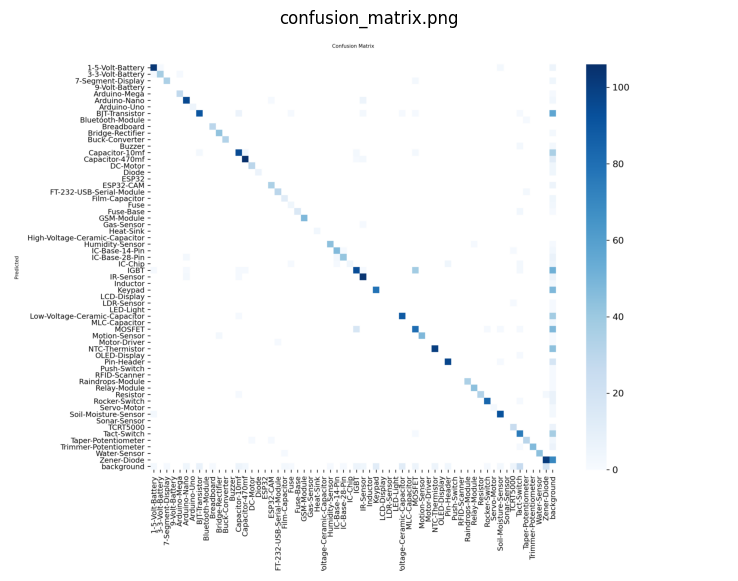

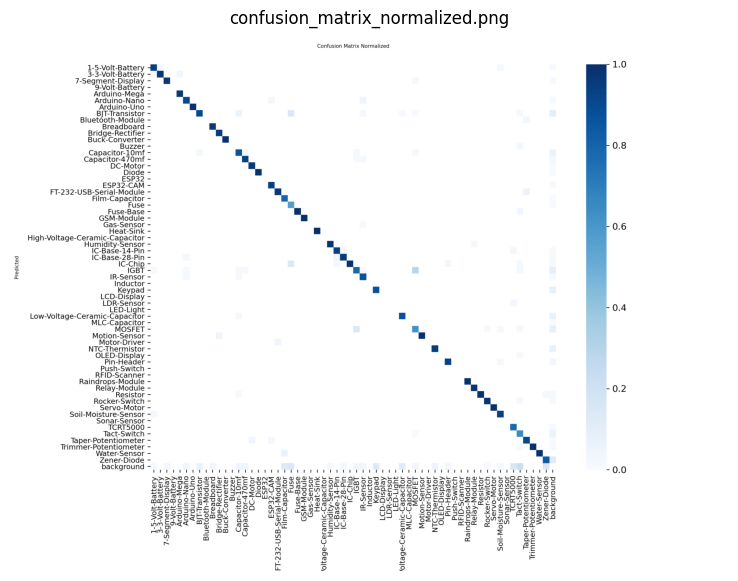

In [14]:
val_results = onnx_model.val(
    data    = str(yaml_path),
    split   = "val",
    imgsz   = TRAIN_CONFIG["imgsz"],
    device  = BASE_CONFIG["device"],
    project = str(PROJECT_DIR),
    name    = "validation",
    plots   = True
)

val_p = float(val_results.box.mp)
val_r = float(val_results.box.mr)

val_metrics = {
    "Precision": val_p,
    "Recall"   : val_r,
    "F1-Score" : 2 * val_p * val_r / (val_p + val_r + 1e-9),
    "mAP50"    : float(val_results.box.map50),
    "mAP50-95" : float(val_results.box.map)
}

print("=== VALIDATION ===")
for name, value in val_metrics.items():
    print(f"  {name:10s}: {value:.4f}")

tampilkan_gambar_evaluasi(
    Path(val_results.save_dir),
    "Gambar Evaluasi Validation"
)

## Cell 15 — Evaluasi Final pada Test Set

Cell ini adalah pengujian akhir. Model ONNX dievaluasi pada data `test`, yaitu data yang tidak pernah dipakai untuk melatih model maupun untuk memilih bobot terbaik. Karena itu hasilnya adalah gambaran paling jujur tentang kemampuan model pada gambar baru, dan inilah angka yang sebaiknya dilaporkan sebagai performa akhir.

Metrik yang dihitung sama dengan validasi: Precision, Recall, F1-Score, mAP50, dan mAP50-95. Nilainya dicetak sebagai rata-rata semua kelas, dan Ultralytics juga menampilkan hasil per kelas di log sehingga terlihat kelas mana yang sudah baik dan kelas mana yang masih lemah. Grafik evaluasi test, seperti confusion matrix dan kurva PR, ditampilkan di notebook dan disimpan di folder `final_test` di dalam `PROJECT_DIR`.

Membandingkan hasil test dengan hasil validasi di Cell 14 berguna untuk melihat apakah performa model stabil. Kalau selisihnya jauh, model mungkin kurang bisa menyesuaikan diri dengan data baru.

Ultralytics 8.4.152  Python-3.10.21 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
Loading C:\Users\tufco\models\best.onnx for ONNX Runtime inference...
requirements: Ultralytics requirement ['onnxruntime-gpu'] not found, attempting AutoUpdate...
WARNING Retry 1/2 failed: Command '['C:\\Users\\tufco\\anaconda3\\envs\\yolo\\python.exe', '-m', 'pip', 'install', '--no-cache-dir', 'onnxruntime-gpu']' returned non-zero exit status 1.
WARNING Retry 2/2 failed: Command '['C:\\Users\\tufco\\anaconda3\\envs\\yolo\\python.exe', '-m', 'pip', 'install', '--no-cache-dir', 'onnxruntime-gpu']' returned non-zero exit status 1.
WARNING requirements:  Command '['C:\\Users\\tufco\\anaconda3\\envs\\yolo\\python.exe', '-m', 'pip', 'install', '--no-cache-dir', 'onnxruntime-gpu']' returned non-zero exit status 1.
   ---------------------------------------- 0.0/244.5 MB ? eta -:--:--
   ---------------------------------------- 1.8/244.5 MB 16.7 MB/s eta 0:00:15
    -------------------------------

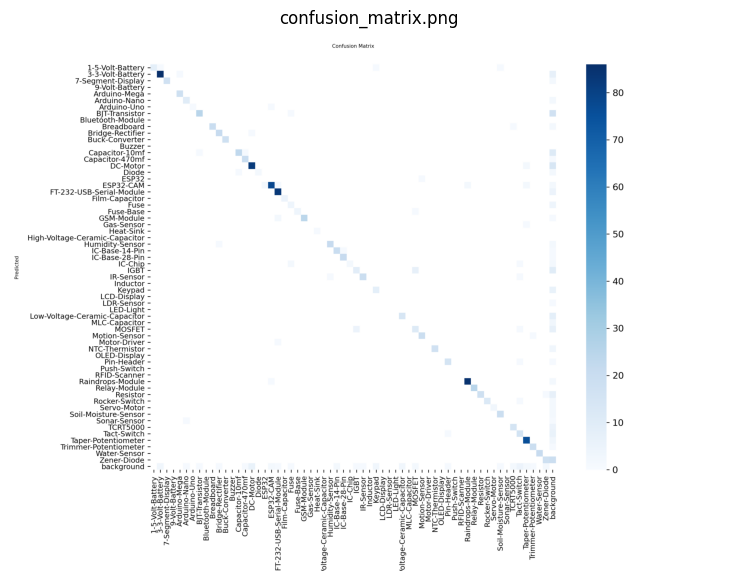

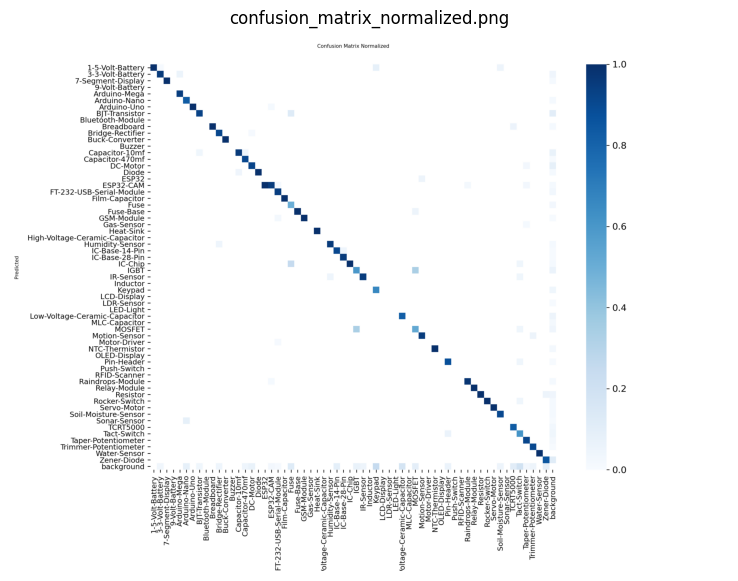

In [15]:
test_results = onnx_model.val(
    data    = str(yaml_path),
    split   = "test",
    imgsz   = TRAIN_CONFIG["imgsz"],
    device  = BASE_CONFIG["device"],
    project = str(PROJECT_DIR),
    name    = "final_test",
    plots   = True
)

test_p = float(test_results.box.mp)
test_r = float(test_results.box.mr)

test_metrics = {
    "Precision": test_p,
    "Recall"   : test_r,
    "F1-Score" : 2 * test_p * test_r / (test_p + test_r + 1e-9),
    "mAP50"    : float(test_results.box.map50),
    "mAP50-95" : float(test_results.box.map)
}

print("=== FINAL TEST SET ===")
for name, value in test_metrics.items():
    print(f"  {name:10s}: {value:.4f}")

tampilkan_gambar_evaluasi(
    Path(test_results.save_dir),
    "Gambar Evaluasi Final - Test Set"
)

## Cell 16 — Metrik per Kelas dan Akurasi Deteksi

Nilai rata-rata di Cell 15 menggabungkan semua kelas menjadi satu angka. Dengan banyak kelas, angka itu bisa menyembunyikan kelas yang sebenarnya lemah. Cell ini memecah hasil test set per kelas supaya terlihat kelas mana yang sudah baik dan kelas mana yang bermasalah.

**Tabel per kelas** berisi:
- **Train** dan **Test**: jumlah objek kelas itu di data train dan test, diambil dari Cell 7. Kolom ini memudahkan melihat apakah kelas yang lemah memang punya sedikit contoh training.
- **P** (Precision), **R** (Recall), dan **F1**: ketepatan, kelengkapan, dan gabungan keduanya untuk kelas tersebut.
- **mAP50** dan **mAP50-95**: nilai average precision kelas itu pada IoU 0,5 dan rata-rata IoU 0,5 sampai 0,95.

Tabel diurutkan dari mAP50-95 tertinggi ke terendah. Di bawah tabel ada baris rata-rata, daftar 5 kelas terbaik dan 5 kelas terlemah, serta grafik batang mAP50 per kelas. Kelas yang tidak punya objek sama sekali di test set tidak bisa dinilai, jadi tidak masuk tabel dan disebutkan terpisah.

**Akurasi deteksi** dihitung dari confusion matrix test set (memakai pengaturan bawaan Ultralytics, yaitu confidence 0,25 dan IoU 0,45):
- **TP** (true positive): objek yang terdeteksi dengan kelas yang benar.
- **FP** (false positive): deteksi yang salah, baik karena kelasnya keliru maupun karena mendeteksi sesuatu yang bukan objek.
- **FN** (false negative): objek yang sebenarnya ada tetapi terlewat atau salah kelas.
- **Akurasi deteksi** = TP / (TP + FP + FN).

Perlu dicatat bahwa angka ini bukan metrik bawaan Ultralytics dan bukan metrik standar deteksi objek. Pada deteksi tidak ada true negative yang bisa dihitung seperti pada klasifikasi, sehingga rumusnya memakai TP, FP, dan FN saja. Objek yang salah kelas dihitung sebagai FP sekaligus FN. Untuk laporan, metrik utama yang disarankan tetap Precision, Recall, F1-Score, mAP50, dan mAP50-95, dan akurasi deteksi dipakai sebagai pelengkap dengan keterangan cara menghitungnya.

 ID  Kelas                         Train  Test       P       R      F1   mAP50  mAP50-95
--------------------------------------------------------------------------------------
 25  Heat-Sink                       171     1   0.732   1.000   0.845   0.995     0.995
  6  Arduino-Uno                     201     1   0.602   1.000   0.751   0.995     0.895
  4  Arduino-Mega                    129    19   0.978   0.947   0.963   0.990     0.833
 11  Buck-Converter                  117    18   1.000   0.976   0.988   0.995     0.816
  9  Breadboard                      130    20   0.952   0.997   0.974   0.959     0.815
 59  Water-Sensor                    165    21   0.983   1.000   0.992   0.995     0.808
 10  Bridge-Rectifier                162    23   0.953   0.888   0.920   0.985     0.781
 48  Raindrops-Module                 65    87   0.982   0.989   0.985   0.994     0.751
 49  Relay-Module                    158    25   0.984   1.000   0.992   0.995     0.741
 27  Humidity-Sensor   

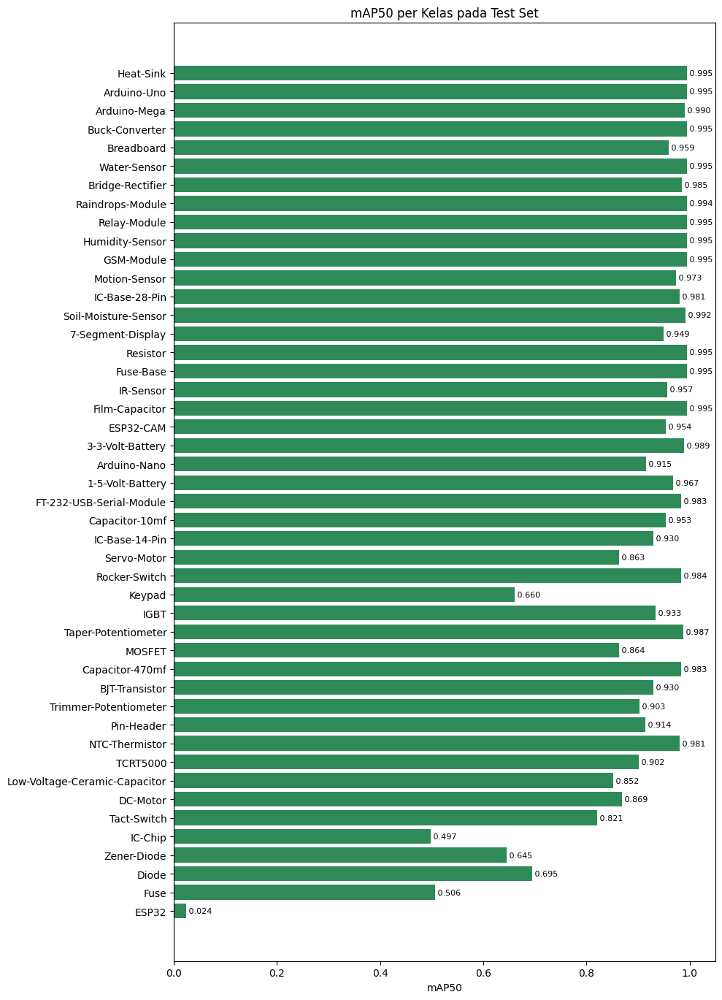


AKURASI DETEKSI (TEST SET)
  TP (benar)            : 1053
  FP (deteksi salah)    : 218
  FN (objek terlewat)   : 96
  Akurasi deteksi       : 0.7703  [TP / (TP + FP + FN)]


In [16]:
box          = test_results.box
nama_kelas   = data["names"]
jumlah_kelas = len(nama_kelas)

# ---------- Metrik per kelas (hanya kelas yang punya objek di test set) ----------
per_kelas = {}
for idx, c in enumerate(box.ap_class_index):
    per_kelas[int(c)] = {
        "P"   : float(box.p[idx]),
        "R"   : float(box.r[idx]),
        "F1"  : float(box.f1[idx]),
        "AP50": float(box.ap50[idx]),
        "AP"  : float(box.ap[idx]),
    }

def n_objek(split, class_id):
    """Jumlah objek per kelas dari Cell 7 (jika sudah dijalankan)."""
    if "jumlah_objek" in globals():
        return jumlah_objek[split][class_id]
    return "-"

urutan = sorted(per_kelas, key=lambda k: per_kelas[k]["AP"], reverse=True)

print(f"{'ID':>3}  {'Kelas':<28}{'Train':>7}{'Test':>6}{'P':>8}{'R':>8}{'F1':>8}{'mAP50':>8}{'mAP50-95':>10}")
print("-" * 86)

for k in urutan:
    m = per_kelas[k]
    print(
        f"{k:>3}  {nama_kelas[k]:<28}{n_objek('train', k):>7}{n_objek('test', k):>6}"
        f"{m['P']:>8.3f}{m['R']:>8.3f}{m['F1']:>8.3f}{m['AP50']:>8.3f}{m['AP']:>10.3f}"
    )

print("-" * 86)
rata_p  = float(box.mp)
rata_r  = float(box.mr)
rata_f1 = 2 * rata_p * rata_r / (rata_p + rata_r + 1e-9)
print(
    f"{'':>3}  {'RATA-RATA':<28}{'':>7}{'':>6}"
    f"{rata_p:>8.3f}{rata_r:>8.3f}{rata_f1:>8.3f}{float(box.map50):>8.3f}{float(box.map):>10.3f}"
)

# ---------- Kelas terbaik dan terlemah ----------
print("\n5 kelas terbaik (mAP50-95):")
for k in urutan[:5]:
    print(f"  {nama_kelas[k]:<28} {per_kelas[k]['AP']:.3f}")

print("\n5 kelas terlemah (mAP50-95):")
for k in urutan[-5:][::-1]:
    print(f"  {nama_kelas[k]:<28} {per_kelas[k]['AP']:.3f}")

tanpa_objek = [nama_kelas[k] for k in range(jumlah_kelas) if k not in per_kelas]
if tanpa_objek:
    print("\nKelas tanpa objek di test set (tidak bisa dinilai):", ", ".join(tanpa_objek))

# ---------- Grafik mAP50 per kelas ----------
nama_grafik  = [nama_kelas[k] for k in urutan]
nilai_grafik = [per_kelas[k]["AP50"] for k in urutan]

fig, ax = plt.subplots(figsize=(10, max(6, 0.3 * len(urutan))))
batang = ax.barh(nama_grafik, nilai_grafik, color="seagreen")
ax.invert_yaxis()
ax.set_xlim(0, 1.05)
ax.set_xlabel("mAP50")
ax.set_title("mAP50 per Kelas pada Test Set")

for b, v in zip(batang, nilai_grafik):
    ax.text(v, b.get_y() + b.get_height() / 2, f" {v:.3f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

# ---------- Akurasi deteksi (turunan dari confusion matrix) ----------
cm = getattr(test_results, "confusion_matrix", None)

print("\n" + "=" * 60)
print("AKURASI DETEKSI (TEST SET)")
print("=" * 60)

if cm is not None:
    matrix = cm.matrix
    tp = float(sum(matrix[i, i] for i in range(jumlah_kelas)))
    fp = float(matrix[:jumlah_kelas, :].sum() - tp)
    fn = float(matrix[:, :jumlah_kelas].sum() - tp)
    akurasi_deteksi = tp / (tp + fp + fn + 1e-9)

    print(f"  TP (benar)            : {int(tp)}")
    print(f"  FP (deteksi salah)    : {int(fp)}")
    print(f"  FN (objek terlewat)   : {int(fn)}")
    print(f"  Akurasi deteksi       : {akurasi_deteksi:.4f}  [TP / (TP + FP + FN)]")
else:
    print("  Confusion matrix tidak tersedia pada hasil test.")

## Cell 17 — Prediksi pada Beberapa Gambar Test

Metrik memberi angka, sedangkan cell ini memperlihatkan langsung bagaimana model ONNX mendeteksi komponen pada gambar. Notebook mengambil 12 gambar pertama dari folder `test` (diurutkan berdasarkan nama file, bukan dipilih acak). Kalau gambar test kurang dari 12, semuanya dipakai.

Model ONNX diekspor dengan batch tetap 1 (`dynamic=False` pada Cell 13), sehingga gambar tidak bisa dikirim sekaligus dalam satu daftar. Karena itu gambar diprediksi **satu per satu** di dalam perulangan. Kalau 12 gambar dikirim bersamaan, onnxruntime menolaknya dengan error `Got invalid dimensions for input ... Got: 12 Expected: 1`.

Prediksi dijalankan dengan `conf=0.25`, artinya hanya deteksi dengan confidence minimal 25% yang ditampilkan, sedangkan deteksi yang lebih ragu dibuang. Ukuran gambar `imgsz` disamakan dengan ukuran training (640). Hasil prediksi juga disimpan sebagai gambar di folder `prediction_samples` di dalam `PROJECT_DIR`.

Untuk setiap gambar, notebook menampilkan:
- gambar dengan bounding box, nama kelas, dan nilai confidence di setiap objek yang terdeteksi,
- jumlah objek yang terdeteksi,
- daftar tiap objek beserta nama kelas dan confidence-nya, atau keterangan bahwa tidak ada objek yang terdeteksi.

Dari tampilan ini kita bisa menilai apakah kotaknya pas, apakah ada objek yang terlewat, dan apakah ada kelas yang sering tertukar.

Jumlah gambar test yang ditemukan: 205
Jumlah gambar yang digunakan untuk visualisasi: 12
Loading C:\Users\tufco\models\best.onnx for ONNX Runtime inference...
requirements: Ultralytics requirement ['onnxruntime-gpu'] not found, attempting AutoUpdate...
WARNING Retry 1/2 failed: Command '['C:\\Users\\tufco\\anaconda3\\envs\\yolo\\python.exe', '-m', 'pip', 'install', '--no-cache-dir', 'onnxruntime-gpu']' returned non-zero exit status 1.
WARNING Retry 2/2 failed: Command '['C:\\Users\\tufco\\anaconda3\\envs\\yolo\\python.exe', '-m', 'pip', 'install', '--no-cache-dir', 'onnxruntime-gpu']' returned non-zero exit status 1.
WARNING requirements:  Command '['C:\\Users\\tufco\\anaconda3\\envs\\yolo\\python.exe', '-m', 'pip', 'install', '--no-cache-dir', 'onnxruntime-gpu']' returned non-zero exit status 1.
   ---------------------------------------- 0.0/244.5 MB ? eta -:--:--
   ---------------------------------------- 1.6/244.5 MB 13.9 MB/s eta 0:00:18
    -------------------------------------

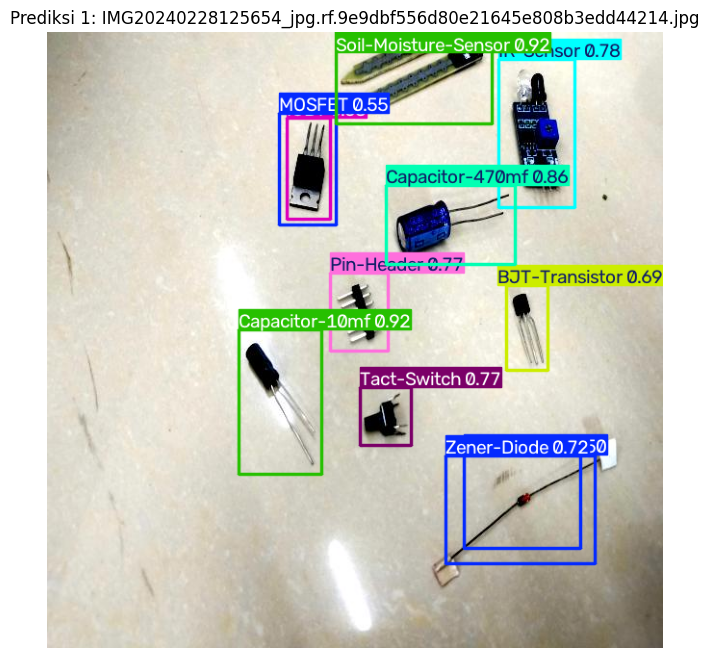

Gambar 1: IMG20240228125654_jpg.rf.9e9dbf556d80e21645e808b3edd44214.jpg
Jumlah objek terdeteksi: 11
  Objek 1: Soil-Moisture-Sensor (confidence=0.924)
  Objek 2: Capacitor-10mf (confidence=0.916)
  Objek 3: Capacitor-470mf (confidence=0.863)
  Objek 4: IR-Sensor (confidence=0.783)
  Objek 5: Pin-Header (confidence=0.774)
  Objek 6: Tact-Switch (confidence=0.769)
  Objek 7: Zener-Diode (confidence=0.719)
  Objek 8: BJT-Transistor (confidence=0.691)
  Objek 9: MOSFET (confidence=0.552)
  Objek 10: IGBT (confidence=0.533)
  Objek 11: Zener-Diode (confidence=0.496)
------------------------------------------------------------
Results saved to C:\Users\tufco\electrocom61_yolov8n_runs\prediction_samples


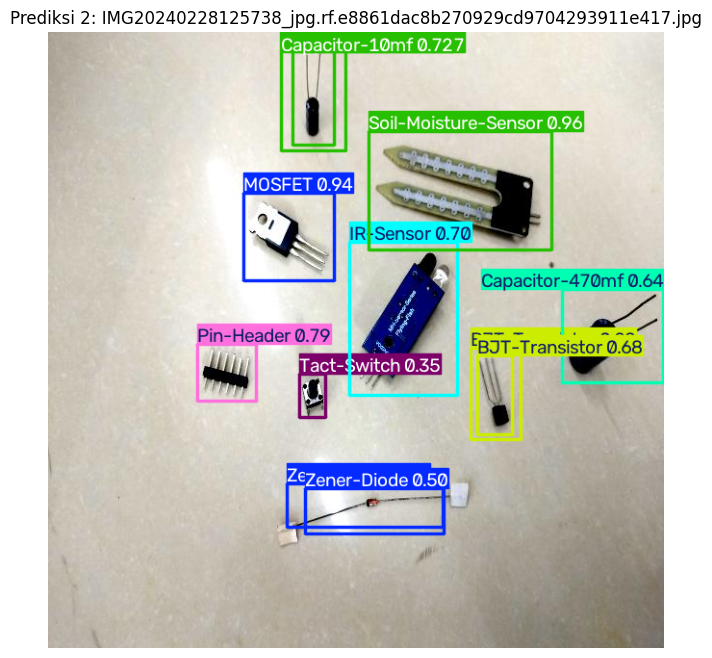

Gambar 2: IMG20240228125738_jpg.rf.e8861dac8b270929cd9704293911e417.jpg
Jumlah objek terdeteksi: 12
  Objek 1: Soil-Moisture-Sensor (confidence=0.958)
  Objek 2: MOSFET (confidence=0.939)
  Objek 3: Pin-Header (confidence=0.794)
  Objek 4: Capacitor-10mf (confidence=0.723)
  Objek 5: IR-Sensor (confidence=0.697)
  Objek 6: BJT-Transistor (confidence=0.676)
  Objek 7: Capacitor-470mf (confidence=0.642)
  Objek 8: Zener-Diode (confidence=0.504)
  Objek 9: Zener-Diode (confidence=0.378)
  Objek 10: Capacitor-10mf (confidence=0.369)
  Objek 11: Tact-Switch (confidence=0.346)
  Objek 12: BJT-Transistor (confidence=0.286)
------------------------------------------------------------
Results saved to C:\Users\tufco\electrocom61_yolov8n_runs\prediction_samples


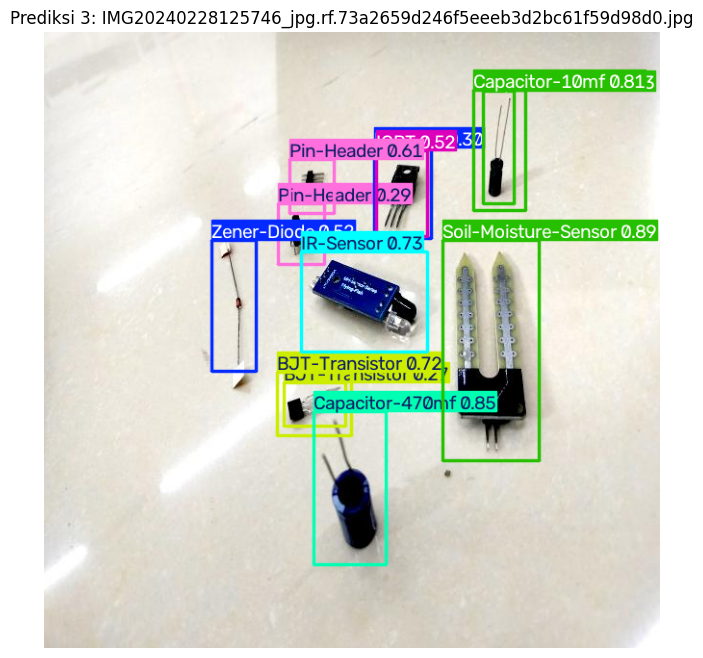

Gambar 3: IMG20240228125746_jpg.rf.73a2659d246f5eeeb3d2bc61f59d98d0.jpg
Jumlah objek terdeteksi: 12
  Objek 1: Soil-Moisture-Sensor (confidence=0.890)
  Objek 2: Capacitor-470mf (confidence=0.846)
  Objek 3: Capacitor-10mf (confidence=0.814)
  Objek 4: IR-Sensor (confidence=0.726)
  Objek 5: BJT-Transistor (confidence=0.721)
  Objek 6: Pin-Header (confidence=0.607)
  Objek 7: Zener-Diode (confidence=0.522)
  Objek 8: IGBT (confidence=0.517)
  Objek 9: Capacitor-10mf (confidence=0.328)
  Objek 10: MOSFET (confidence=0.305)
  Objek 11: Pin-Header (confidence=0.291)
  Objek 12: BJT-Transistor (confidence=0.272)
------------------------------------------------------------
Results saved to C:\Users\tufco\electrocom61_yolov8n_runs\prediction_samples


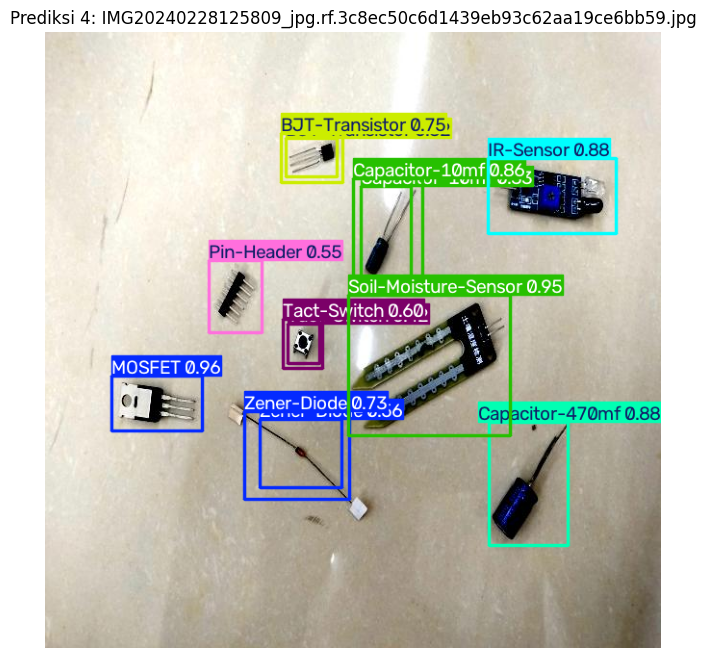

Gambar 4: IMG20240228125809_jpg.rf.3c8ec50c6d1439eb93c62aa19ce6bb59.jpg
Jumlah objek terdeteksi: 13
  Objek 1: MOSFET (confidence=0.959)
  Objek 2: Soil-Moisture-Sensor (confidence=0.947)
  Objek 3: Capacitor-470mf (confidence=0.885)
  Objek 4: IR-Sensor (confidence=0.883)
  Objek 5: Capacitor-10mf (confidence=0.860)
  Objek 6: BJT-Transistor (confidence=0.753)
  Objek 7: Zener-Diode (confidence=0.733)
  Objek 8: Tact-Switch (confidence=0.598)
  Objek 9: Zener-Diode (confidence=0.556)
  Objek 10: Pin-Header (confidence=0.549)
  Objek 11: Tact-Switch (confidence=0.416)
  Objek 12: Capacitor-10mf (confidence=0.332)
  Objek 13: BJT-Transistor (confidence=0.324)
------------------------------------------------------------
Results saved to C:\Users\tufco\electrocom61_yolov8n_runs\prediction_samples


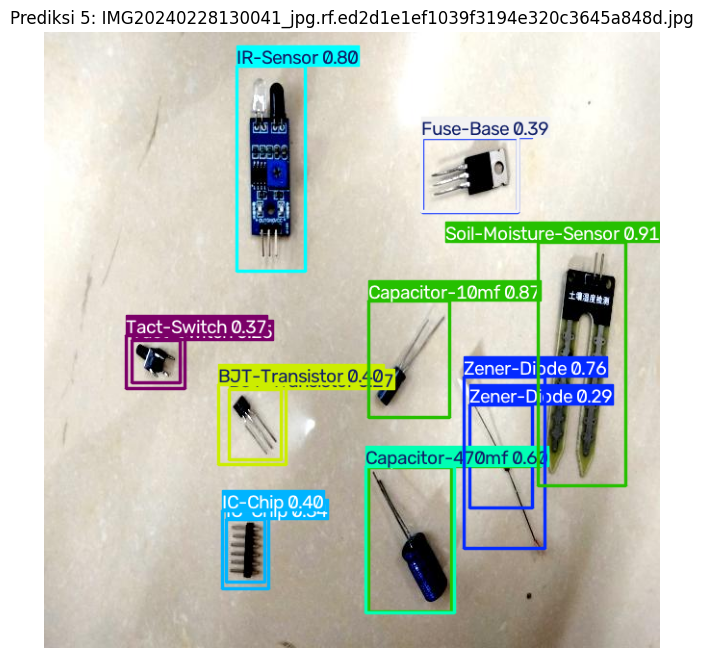

Gambar 5: IMG20240228130041_jpg.rf.ed2d1e1ef1039f3194e320c3645a848d.jpg
Jumlah objek terdeteksi: 15
  Objek 1: Soil-Moisture-Sensor (confidence=0.909)
  Objek 2: Capacitor-10mf (confidence=0.868)
  Objek 3: IR-Sensor (confidence=0.801)
  Objek 4: Zener-Diode (confidence=0.762)
  Objek 5: Capacitor-470mf (confidence=0.599)
  Objek 6: BJT-Transistor (confidence=0.398)
  Objek 7: IC-Chip (confidence=0.397)
  Objek 8: Fuse-Base (confidence=0.389)
  Objek 9: Tact-Switch (confidence=0.372)
  Objek 10: IC-Chip (confidence=0.341)
  Objek 11: MOSFET (confidence=0.315)
  Objek 12: Zener-Diode (confidence=0.291)
  Objek 13: BJT-Transistor (confidence=0.275)
  Objek 14: Capacitor-10mf (confidence=0.271)
  Objek 15: Tact-Switch (confidence=0.255)
------------------------------------------------------------
Results saved to C:\Users\tufco\electrocom61_yolov8n_runs\prediction_samples


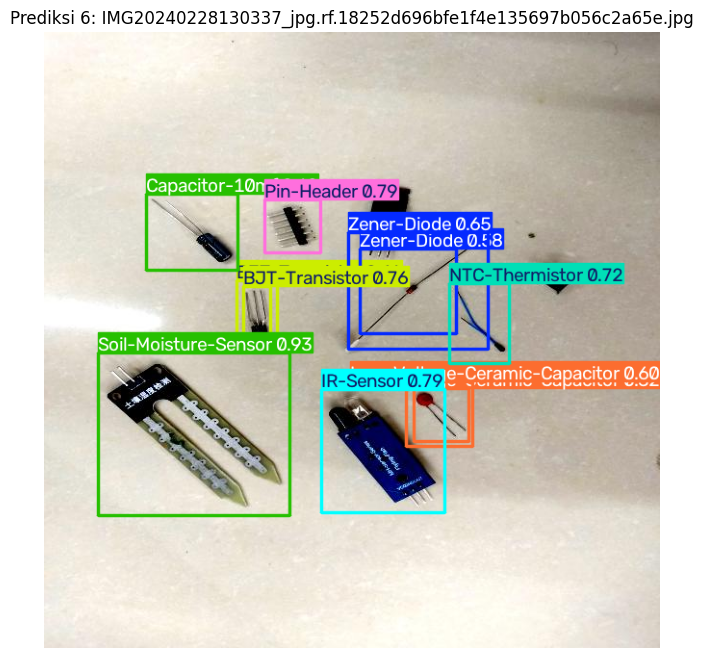

Gambar 6: IMG20240228130337_jpg.rf.18252d696bfe1f4e135697b056c2a65e.jpg
Jumlah objek terdeteksi: 11
  Objek 1: Soil-Moisture-Sensor (confidence=0.934)
  Objek 2: Pin-Header (confidence=0.793)
  Objek 3: IR-Sensor (confidence=0.788)
  Objek 4: BJT-Transistor (confidence=0.765)
  Objek 5: NTC-Thermistor (confidence=0.719)
  Objek 6: Capacitor-10mf (confidence=0.693)
  Objek 7: Zener-Diode (confidence=0.652)
  Objek 8: Low-Voltage-Ceramic-Capacitor (confidence=0.600)
  Objek 9: Zener-Diode (confidence=0.580)
  Objek 10: BJT-Transistor (confidence=0.408)
  Objek 11: Low-Voltage-Ceramic-Capacitor (confidence=0.320)
------------------------------------------------------------
Results saved to C:\Users\tufco\electrocom61_yolov8n_runs\prediction_samples


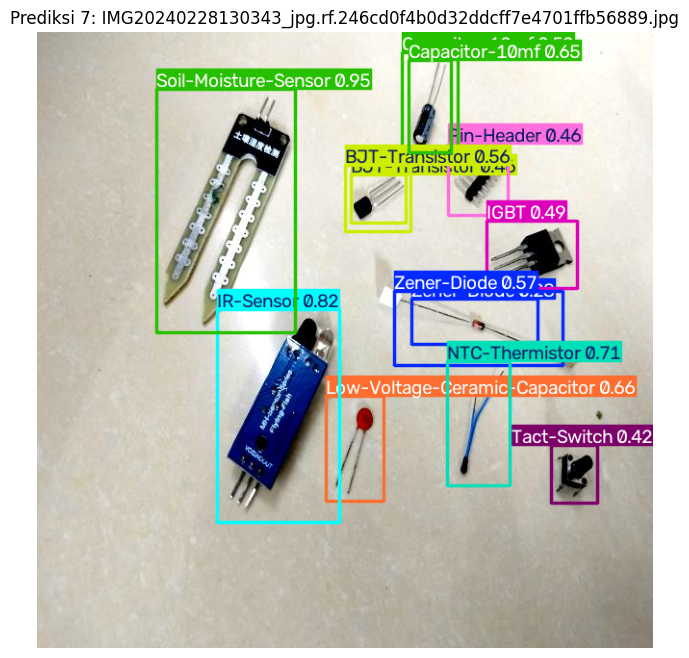

Gambar 7: IMG20240228130343_jpg.rf.246cd0f4b0d32ddcff7e4701ffb56889.jpg
Jumlah objek terdeteksi: 13
  Objek 1: Soil-Moisture-Sensor (confidence=0.954)
  Objek 2: IR-Sensor (confidence=0.816)
  Objek 3: NTC-Thermistor (confidence=0.707)
  Objek 4: Low-Voltage-Ceramic-Capacitor (confidence=0.663)
  Objek 5: Capacitor-10mf (confidence=0.650)
  Objek 6: Zener-Diode (confidence=0.574)
  Objek 7: BJT-Transistor (confidence=0.555)
  Objek 8: Capacitor-10mf (confidence=0.498)
  Objek 9: IGBT (confidence=0.489)
  Objek 10: Pin-Header (confidence=0.465)
  Objek 11: BJT-Transistor (confidence=0.461)
  Objek 12: Tact-Switch (confidence=0.415)
  Objek 13: Zener-Diode (confidence=0.278)
------------------------------------------------------------
Results saved to C:\Users\tufco\electrocom61_yolov8n_runs\prediction_samples


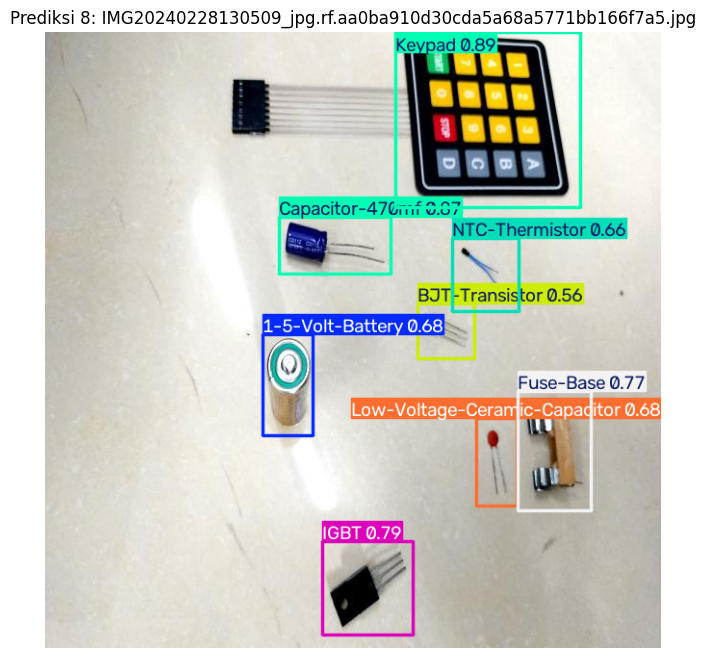

Gambar 8: IMG20240228130509_jpg.rf.aa0ba910d30cda5a68a5771bb166f7a5.jpg
Jumlah objek terdeteksi: 8
  Objek 1: Keypad (confidence=0.891)
  Objek 2: Capacitor-470mf (confidence=0.870)
  Objek 3: IGBT (confidence=0.791)
  Objek 4: Fuse-Base (confidence=0.770)
  Objek 5: Low-Voltage-Ceramic-Capacitor (confidence=0.681)
  Objek 6: 1-5-Volt-Battery (confidence=0.677)
  Objek 7: NTC-Thermistor (confidence=0.657)
  Objek 8: BJT-Transistor (confidence=0.559)
------------------------------------------------------------
Results saved to C:\Users\tufco\electrocom61_yolov8n_runs\prediction_samples


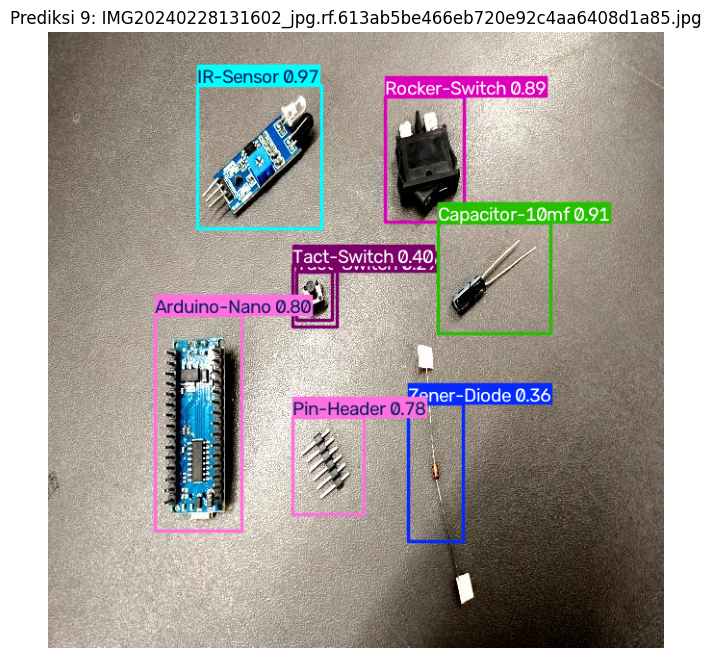

Gambar 9: IMG20240228131602_jpg.rf.613ab5be466eb720e92c4aa6408d1a85.jpg
Jumlah objek terdeteksi: 8
  Objek 1: IR-Sensor (confidence=0.972)
  Objek 2: Capacitor-10mf (confidence=0.909)
  Objek 3: Rocker-Switch (confidence=0.886)
  Objek 4: Arduino-Nano (confidence=0.802)
  Objek 5: Pin-Header (confidence=0.781)
  Objek 6: Tact-Switch (confidence=0.400)
  Objek 7: Zener-Diode (confidence=0.357)
  Objek 8: Tact-Switch (confidence=0.291)
------------------------------------------------------------
Results saved to C:\Users\tufco\electrocom61_yolov8n_runs\prediction_samples


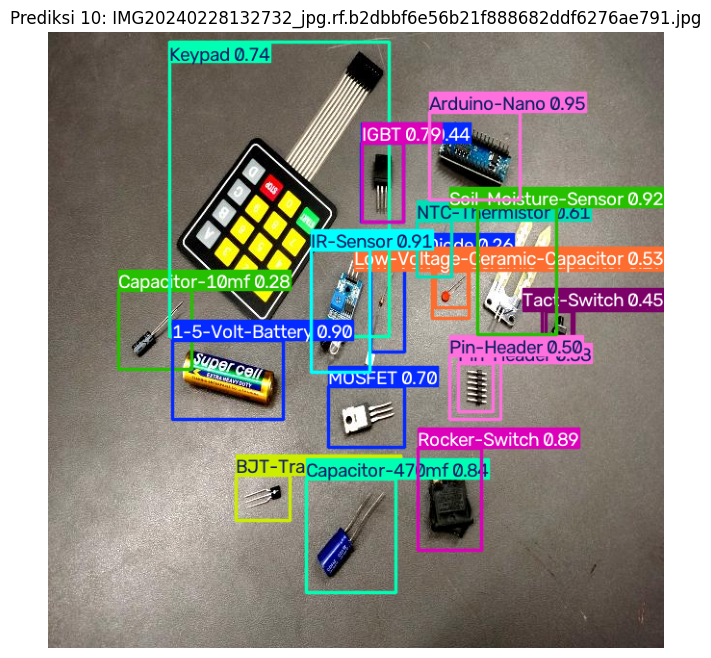

Gambar 10: IMG20240228132732_jpg.rf.b2dbbf6e56b21f888682ddf6276ae791.jpg
Jumlah objek terdeteksi: 20
  Objek 1: Arduino-Nano (confidence=0.951)
  Objek 2: Soil-Moisture-Sensor (confidence=0.924)
  Objek 3: IR-Sensor (confidence=0.906)
  Objek 4: 1-5-Volt-Battery (confidence=0.900)
  Objek 5: Rocker-Switch (confidence=0.893)
  Objek 6: Capacitor-470mf (confidence=0.843)
  Objek 7: IGBT (confidence=0.788)
  Objek 8: BJT-Transistor (confidence=0.744)
  Objek 9: Keypad (confidence=0.735)
  Objek 10: MOSFET (confidence=0.703)
  Objek 11: NTC-Thermistor (confidence=0.613)
  Objek 12: Low-Voltage-Ceramic-Capacitor (confidence=0.535)
  Objek 13: Pin-Header (confidence=0.503)
  Objek 14: Tact-Switch (confidence=0.455)
  Objek 15: MOSFET (confidence=0.440)
  Objek 16: Pin-Header (confidence=0.383)
  Objek 17: Tact-Switch (confidence=0.296)
  Objek 18: Low-Voltage-Ceramic-Capacitor (confidence=0.287)
  Objek 19: Capacitor-10mf (confidence=0.282)
  Objek 20: Zener-Diode (confidence=0.261)
--------

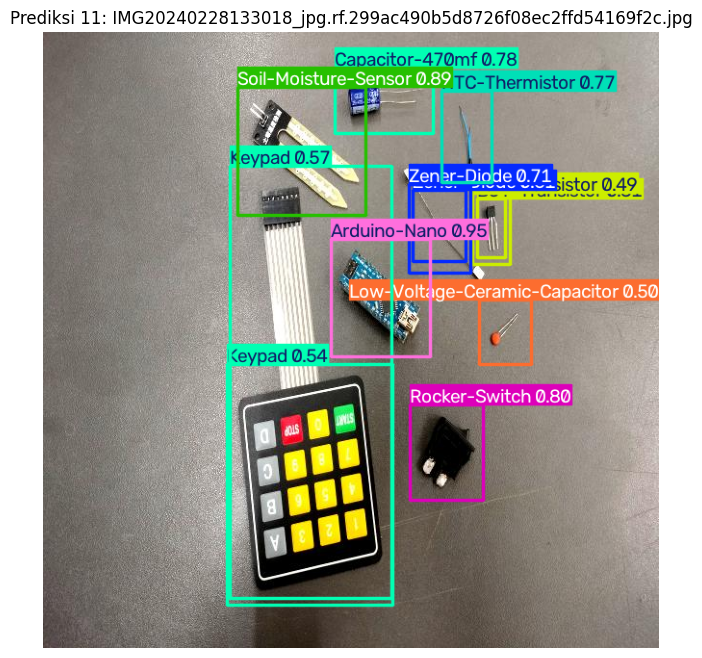

Gambar 11: IMG20240228133018_jpg.rf.299ac490b5d8726f08ec2ffd54169f2c.jpg
Jumlah objek terdeteksi: 12
  Objek 1: Arduino-Nano (confidence=0.948)
  Objek 2: Soil-Moisture-Sensor (confidence=0.887)
  Objek 3: Rocker-Switch (confidence=0.804)
  Objek 4: Capacitor-470mf (confidence=0.784)
  Objek 5: NTC-Thermistor (confidence=0.770)
  Objek 6: Zener-Diode (confidence=0.707)
  Objek 7: Zener-Diode (confidence=0.614)
  Objek 8: Keypad (confidence=0.571)
  Objek 9: Keypad (confidence=0.539)
  Objek 10: Low-Voltage-Ceramic-Capacitor (confidence=0.497)
  Objek 11: BJT-Transistor (confidence=0.490)
  Objek 12: BJT-Transistor (confidence=0.314)
------------------------------------------------------------
Results saved to C:\Users\tufco\electrocom61_yolov8n_runs\prediction_samples


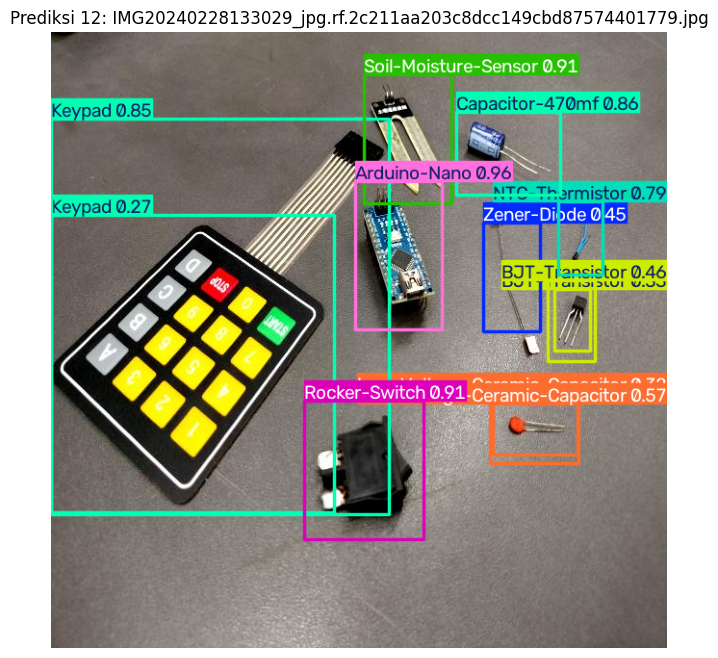

Gambar 12: IMG20240228133029_jpg.rf.2c211aa203c8dcc149cbd87574401779.jpg
Jumlah objek terdeteksi: 12
  Objek 1: Arduino-Nano (confidence=0.961)
  Objek 2: Rocker-Switch (confidence=0.910)
  Objek 3: Soil-Moisture-Sensor (confidence=0.909)
  Objek 4: Capacitor-470mf (confidence=0.858)
  Objek 5: Keypad (confidence=0.855)
  Objek 6: NTC-Thermistor (confidence=0.792)
  Objek 7: Low-Voltage-Ceramic-Capacitor (confidence=0.571)
  Objek 8: BJT-Transistor (confidence=0.461)
  Objek 9: Zener-Diode (confidence=0.445)
  Objek 10: BJT-Transistor (confidence=0.331)
  Objek 11: Low-Voltage-Ceramic-Capacitor (confidence=0.323)
  Objek 12: Keypad (confidence=0.270)
------------------------------------------------------------


In [17]:
test_images_path = dataset_path / "test" / "images"

test_images = sorted([
    p for p in test_images_path.iterdir()
    if p.is_file() and p.suffix.lower() in image_extensions
])

print("Jumlah gambar test yang ditemukan:", len(test_images))

jumlah_gambar_prediksi = min(12, len(test_images))
sample_images          = test_images[:jumlah_gambar_prediksi]

print(f"Jumlah gambar yang digunakan untuk visualisasi: {jumlah_gambar_prediksi}")

# Model ONNX memiliki batch tetap 1, jadi gambar diprediksi satu per satu
for i, image_path in enumerate(sample_images, start=1):
    result = onnx_model.predict(
        source   = str(image_path),
        imgsz    = TRAIN_CONFIG["imgsz"],
        conf     = 0.25,
        device   = BASE_CONFIG["device"],
        save     = True,
        project  = str(PROJECT_DIR),
        name     = "prediction_samples",
        exist_ok = True,
        verbose  = False
    )[0]

    hasil = result.plot()
    hasil = hasil[:, :, ::-1]

    plt.figure(figsize=(8, 8))
    plt.imshow(hasil)
    plt.axis("off")
    plt.title(f"Prediksi {i}: {image_path.name}")
    plt.show()

    print(f"Gambar {i}: {image_path.name}")
    print("Jumlah objek terdeteksi:", len(result.boxes))

    if len(result.boxes) > 0:
        for j, box in enumerate(result.boxes, start=1):
            class_id   = int(box.cls[0])
            confidence = float(box.conf[0])
            class_name = data["names"][class_id]
            print(f"  Objek {j}: {class_name} (confidence={confidence:.3f})")
    else:
        print("  Tidak ada objek yang terdeteksi.")

    print("-" * 60)

## Cell 18 — Ringkasan Hasil

Cell terakhir merangkum seluruh hasil dalam satu tampilan supaya mudah disalin ke laporan atau dokumentasi. Isinya:
- model dasar yang dipakai (YOLOv8n),
- konfigurasi training: jumlah epoch maksimum, patience (early stopping), ukuran gambar, dan batch size,
- hasil validasi: Precision, Recall, F1-Score, mAP50, dan mAP50-95,
- hasil test set dengan metrik yang sama,
- lokasi file `best.onnx` yang siap dibawa ke Raspberry Pi 4.

Metrik object detection yang dipakai di sini adalah Precision, Recall, F1-Score, mAP50, dan mAP50-95. Akurasi (accuracy) seperti pada klasifikasi biasa bukan metrik standar untuk deteksi objek, karena model harus menebak kelas sekaligus posisi kotaknya. Sebagai pelengkap, Cell 16 menghitung akurasi deteksi yang diturunkan dari confusion matrix.

Setiap bagian punya pengecekan sendiri. Kalau sebuah cell sebelumnya belum dijalankan, bagian yang bersangkutan menampilkan pesan yang meminta cell itu dijalankan, tidak error.

In [18]:
print("=" * 70)
print("RINGKASAN YOLOv8n - ELECTROCOM61")
print("(Dioptimalkan untuk Raspberry Pi 4)")
print("=" * 70)

print("\nModel Dasar   : YOLOv8n (Nano)")

print("\nKonfigurasi Training:")
print("  Epoch      :", TRAIN_CONFIG["epochs"])
print("  Image Size :", TRAIN_CONFIG["imgsz"])
print("  Batch Size :", TRAIN_CONFIG["batch"])
print("  Patience   :", TRAIN_CONFIG["patience"], "(early stopping)")

print("\nHasil Validation:")
if "val_metrics" in globals():
    for name, value in val_metrics.items():
        print(f"  {name:10s}: {value:.4f}")
else:
    print("  Metrik Validation belum tersedia.")
    print("  Jalankan kembali cell validasi.")

print("\nHasil Test Set:")
if "test_metrics" in globals():
    for name, value in test_metrics.items():
        print(f"  {name:10s}: {value:.4f}")
else:
    print("  Metrik Test Set belum tersedia.")
    print("  Jalankan kembali cell evaluasi Test Set.")

print("\nFile Model Siap:")
if "dest_onnx" in globals() and dest_onnx.exists():
    print(f"  ✅ {dest_onnx.resolve()} (siap untuk Raspberry Pi 4)")
else:
    print("  ⚠️  Jalankan Cell 13 untuk mengekspor model ke ONNX.")

print("\n" + "=" * 70)
print("RINGKASAN SELESAI")
print("=" * 70)

RINGKASAN YOLOv8n - ELECTROCOM61
(Dioptimalkan untuk Raspberry Pi 4)

Model Dasar   : YOLOv8n (Nano)

Konfigurasi Training:
  Epoch      : 50
  Image Size : 640
  Batch Size : 8
  Patience   : 10 (early stopping)

Hasil Validation:
  Precision : 0.8723
  Recall    : 0.8974
  F1-Score  : 0.8847
  mAP50     : 0.9164
  mAP50-95  : 0.5882

Hasil Test Set:
  Precision : 0.8495
  Recall    : 0.8433
  F1-Score  : 0.8464
  mAP50     : 0.8965
  mAP50-95  : 0.5916

File Model Siap:
  ✅ C:\Users\tufco\models\best.onnx (siap untuk Raspberry Pi 4)

RINGKASAN SELESAI
